In [2]:
#importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_pipe
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from time import time
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree


import warnings
warnings.filterwarnings('ignore')

from sklearn import set_config
set_config(transform_output='pandas')

from datetime import datetime

RSEED = 101

In [3]:
#Loading the data
client_data_train = pd.read_csv('data/train/client_train.csv')
invoice_data_train = pd.read_csv('data/train/invoice_train.csv')

In [4]:
client_data_train

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0
...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0
135489,63,train_Client_99996,11,311,25/10/2012,0.0
135490,63,train_Client_99997,11,311,22/11/2011,0.0
135491,60,train_Client_99998,11,101,22/12/1993,0.0


In [5]:
invoice_data_train

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,ELEC
4476745,train_Client_99998,2005-12-19,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,ELEC
4476746,train_Client_99999,1996-09-25,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,ELEC
4476747,train_Client_99999,1996-05-28,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,ELEC


In [6]:
client_data_train.shape

(135493, 6)

In [7]:
invoice_data_train.shape

(4476749, 16)

From the shape of these two data it is visible that there is a difference in shape. If we can recall the goal of the company is to detect which clients are involved in fraudulant activities and not to catch which bills are fraudulant. It can be asumed that there are clients who have multiple bills, which leads to the difference in shape. let us test the hypothesis

In [8]:
bill_counts = invoice_data_train.groupby('client_id').size().reset_index(name='Bill_Count')

# Display the result
bill_counts

,client_id,Bill_Count
0,train_Client_0,35
1,train_Client_1,37
2,train_Client_10,18
3,train_Client_100,20
4,train_Client_1000,14
...,...,...
135488,train_Client_99995,71
135489,train_Client_99996,41
135490,train_Client_99997,36
135491,train_Client_99998,2


In [9]:
bill_counts.isnull().sum()

client_id     0
Bill_Count    0
dtype: int64

In [10]:
client_data_train = client_data_train.merge(bill_counts, on='client_id', how='left')

client_data_train


,disrict,client_id,client_catg,region,creation_date,target,Bill_Count
0,60,train_Client_0,11,101,31/12/1994,0.0,35
1,69,train_Client_1,11,107,29/05/2002,0.0,37
2,62,train_Client_10,11,301,13/03/1986,0.0,18
3,69,train_Client_100,11,105,11/07/1996,0.0,20
4,62,train_Client_1000,11,303,14/10/2014,0.0,14
...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2


In [11]:
bill_counts.min()

client_id     train_Client_0
Bill_Count                 1
dtype: object

In [12]:
bill_counts.max()

client_id     train_Client_99999
Bill_Count                   439
dtype: object

In [13]:
client_data_train.head()

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count
0,60,train_Client_0,11,101,31/12/1994,0.0,35
1,69,train_Client_1,11,107,29/05/2002,0.0,37
2,62,train_Client_10,11,301,13/03/1986,0.0,18
3,69,train_Client_100,11,105,11/07/1996,0.0,20
4,62,train_Client_1000,11,303,14/10/2014,0.0,14


In [14]:
invoice_data_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [15]:
client_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
 6   Bill_Count     135493 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 7.2+ MB


In [16]:
invoice_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [17]:
client_data_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
Bill_Count       0
dtype: int64

In [18]:
invoice_data_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [19]:
client_data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,135493.0,63.511222,3.354400,60.0,62.0,62.0,69.0,69.0
client_catg,135493.0,11.512506,4.423761,11.0,11.0,11.0,11.0,51.0
region,135493.0,206.159809,104.207044,101.0,103.0,107.0,307.0,399.0
target,135493.0,0.055841,0.229614,0.0,0.0,0.0,0.0,1.0
Bill_Count,135493.0,33.040445,26.092229,1.0,10.0,30.0,50.0,439.0


In [20]:
invoice_data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [21]:
invoice_data_train.duplicated().sum()

11

In [22]:
#Removing dulpicates because they can mess up the aggregation
invoice_data_train = invoice_data_train.drop_duplicates()

In [23]:
#Check if it worked
invoice_data_train.shape

(4476738, 16)

We have sucesfuly managed to remove the duplicates

Earlier in the client data we saw that there is a column called creation_date. now dates while they can be helpful for the model. For this reason we create some new features where we split the day month and year to seperate columns so that we can feed this data into our model

In [24]:
client_data_train['creation_day']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[0]))
client_data_train['creation_month']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[1]))
client_data_train['creation_year']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[2]))
client_data_train

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014
...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993


Let us take create a new feature in the invoice table. We take new_index and old_index and creeate a new feature called diff_index

In [25]:
invoice_data_train['diff_index']=invoice_data_train['new_index']-invoice_data_train['old_index']
invoice_data_train

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,diff_index
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC,82
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC,1384
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC,123
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC,102
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC,572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,ELEC,535
4476745,train_Client_99998,2005-12-19,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,ELEC,206
4476746,train_Client_99999,1996-09-25,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,ELEC,259
4476747,train_Client_99999,1996-05-28,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,ELEC,603


In [26]:
# Convert Invoice_date to datetime if not already
invoice_data_train['invoice_date'] = pd.to_datetime(invoice_data_train['invoice_date'])

# Sort by Client_id and Invoice_date
invoice_data_train = invoice_data_train.sort_values(by=['client_id', 'invoice_date'])

# Calculate the time difference between consecutive bills for each client
invoice_data_train['time_diff'] = invoice_data_train.groupby('client_id')['invoice_date'].diff().dt.days

# Compute the average frequency of bills (mean of Time_Diff) for each client
frequency_of_bills = (
    invoice_data_train.groupby('client_id')['time_diff']
    .mean()
    .reset_index(name='avg_frequency_of_bills_in_days')
)

# Display the result
frequency_of_bills.head()

,client_id,avg_frequency_of_bills_in_days
0,train_Client_0,144.147059
1,train_Client_1,136.472222
2,train_Client_10,289.470588
3,train_Client_100,140.210526
4,train_Client_1000,121.923077


In [27]:
client_data_train = client_data_train.merge(frequency_of_bills, on='client_id', how='left')


In [28]:
client_data_train

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077
...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004,72.842857
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012,57.675000
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011,80.600000
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993,122.000000


In [29]:
client_data_train.isnull().sum()

disrict                              0
client_id                            0
client_catg                          0
region                               0
creation_date                        0
target                               0
Bill_Count                           0
creation_day                         0
creation_month                       0
creation_year                        0
avg_frequency_of_bills_in_days    4212
dtype: int64

In [30]:
drop_columns = ['invoice_date', 'counter_number', 'counter_statue', 'old_index', 'new_index', 'months_number', 'counter_code', 'time_diff']

In [31]:
invoice_data_train.drop(drop_columns,axis=1,inplace=True)
invoice_data_train

,client_id,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,diff_index
22,train_Client_0,11,6,1,124,0,0,0,ELEC,124
23,train_Client_0,11,6,1,141,0,0,0,ELEC,141
24,train_Client_0,11,6,1,162,0,0,0,ELEC,162
25,train_Client_0,11,6,1,159,0,0,0,ELEC,159
28,train_Client_0,11,6,1,182,0,0,0,ELEC,182
...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,10,9,1,400,135,0,0,ELEC,535
4476745,train_Client_99998,10,6,1,200,6,0,0,ELEC,206
4476748,train_Client_99999,11,6,1,516,0,0,0,ELEC,516
4476747,train_Client_99999,11,6,1,603,0,0,0,ELEC,603


In [32]:
# Add a flag for single-bill clients
client_data_train['single_bill_client'] = client_data_train['avg_frequency_of_bills_in_days'].isnull().astype(int)


In [33]:
client_data_train.head(50)

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077,0
5,69,train_Client_10000,11,103,29/09/1993,0.0,48,29,9,1993,98.425532,0
6,62,train_Client_100000,11,309,07/06/2012,0.0,40,7,6,2012,62.282051,0
7,60,train_Client_100001,11,101,12/04/2006,0.0,78,12,4,2006,64.532468,0
8,62,train_Client_100002,11,301,31/12/2006,0.0,2,31,12,2006,120.000000,0
9,60,train_Client_100003,11,101,25/10/2011,0.0,5,25,10,2011,223.750000,0


In [34]:
# Fill missing values in Frequency_of_Bills
median_frequency = client_data_train['avg_frequency_of_bills_in_days'].median()
client_data_train['avg_frequency_of_bills_in_days'].fillna(median_frequency, inplace=True)
client_data_train.head(50)


,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077,0
5,69,train_Client_10000,11,103,29/09/1993,0.0,48,29,9,1993,98.425532,0
6,62,train_Client_100000,11,309,07/06/2012,0.0,40,7,6,2012,62.282051,0
7,60,train_Client_100001,11,101,12/04/2006,0.0,78,12,4,2006,64.532468,0
8,62,train_Client_100002,11,301,31/12/2006,0.0,2,31,12,2006,120.000000,0
9,60,train_Client_100003,11,101,25/10/2011,0.0,5,25,10,2011,223.750000,0


In [35]:
# Group by client_id and aggregate
aggregated_invoice_data_train = invoice_data_train.groupby('client_id').agg({
    'tarif_type': lambda x: x.mode()[0],  # Mode
    'counter_coefficient': lambda x: x.mode()[0],  # Mode
    'counter_type': lambda x: x.mode()[0],  # Mode
    'reading_remarque': ['min', lambda x: x.mode()[0]],  # Min and Mode
    'consommation_level_1': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_2': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_3': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_4': ['mean', 'std'],  # Mean and Std Dev
    'diff_index': ['mean', 'std']  # Mean and Std Dev
}).reset_index()

# Flatten MultiIndex columns
aggregated_invoice_data_train.columns = ['_'.join(col).strip('_') for col in aggregated_invoice_data_train.columns]

aggregated_invoice_data_train

,client_id,tarif_type_<lambda>,counter_coefficient_<lambda>,counter_type_<lambda>,reading_remarque_min,reading_remarque_<lambda_0>,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,train_Client_0,11,1,ELEC,6,6,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,train_Client_1,11,1,ELEC,6,6,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,train_Client_10,11,1,ELEC,6,6,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,train_Client_100,11,1,ELEC,6,6,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,train_Client_1000,11,1,ELEC,8,9,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,11,1,ELEC,6,6,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,train_Client_99996,40,1,GAZ,6,9,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,train_Client_99997,11,1,ELEC,9,9,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,train_Client_99998,10,1,ELEC,6,6,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [36]:
# Create a dictionary for renaming
column_rename_mapping = {
    'tarif_type_<lambda>': 'tarif_type_mode',
    'counter_coefficient_<lambda>': 'counter_coefficient_mode',
    'counter_type_<lambda>': 'counter_type_mode',
    'reading_remarque_<lambda_0>': 'reading_remarque_mode'
}

# Rename columns
aggregated_invoice_data_train.rename(columns=column_rename_mapping, inplace=True)
aggregated_invoice_data_train

,client_id,tarif_type_mode,counter_coefficient_mode,counter_type_mode,reading_remarque_min,reading_remarque_mode,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,train_Client_0,11,1,ELEC,6,6,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,train_Client_1,11,1,ELEC,6,6,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,train_Client_10,11,1,ELEC,6,6,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,train_Client_100,11,1,ELEC,6,6,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,train_Client_1000,11,1,ELEC,8,9,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,11,1,ELEC,6,6,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,train_Client_99996,40,1,GAZ,6,9,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,train_Client_99997,11,1,ELEC,9,9,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,train_Client_99998,10,1,ELEC,6,6,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [37]:
df_client = client_data_train.copy()
df_invoice = invoice_data_train.copy()
df_aggregated = aggregated_invoice_data_train.copy()

In [38]:
df_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         135493 non-null  int64  
 1   client_id                       135493 non-null  object 
 2   client_catg                     135493 non-null  int64  
 3   region                          135493 non-null  int64  
 4   creation_date                   135493 non-null  object 
 5   target                          135493 non-null  float64
 6   Bill_Count                      135493 non-null  int64  
 7   creation_day                    135493 non-null  int64  
 8   creation_month                  135493 non-null  int64  
 9   creation_year                   135493 non-null  int64  
 10  avg_frequency_of_bills_in_days  135493 non-null  float64
 11  single_bill_client              135493 non-null  int64  
dtypes: float64(2), i

In [39]:
df_invoice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476738 entries, 22 to 4476746
Data columns (total 10 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   tarif_type            int64 
 2   reading_remarque      int64 
 3   counter_coefficient   int64 
 4   consommation_level_1  int64 
 5   consommation_level_2  int64 
 6   consommation_level_3  int64 
 7   consommation_level_4  int64 
 8   counter_type          object
 9   diff_index            int64 
dtypes: int64(8), object(2)
memory usage: 375.7+ MB


In [40]:
df_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   client_id                  135493 non-null  object 
 1   tarif_type_mode            135493 non-null  int64  
 2   counter_coefficient_mode   135493 non-null  int64  
 3   counter_type_mode          135493 non-null  object 
 4   reading_remarque_min       135493 non-null  int64  
 5   reading_remarque_mode      135493 non-null  int64  
 6   consommation_level_1_mean  135493 non-null  float64
 7   consommation_level_1_std   131281 non-null  float64
 8   consommation_level_2_mean  135493 non-null  float64
 9   consommation_level_2_std   131281 non-null  float64
 10  consommation_level_3_mean  135493 non-null  float64
 11  consommation_level_3_std   131281 non-null  float64
 12  consommation_level_4_mean  135493 non-null  float64
 13  consommation_level_4_std   13

In [41]:
# Merge aggregated invoice data with client data
df = pd.merge(df_client, df_aggregated, on='client_id', how='left')
df

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,...,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,...,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,...,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,...,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,...,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,...,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004,...,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012,...,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011,...,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993,...,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         135493 non-null  int64  
 1   client_id                       135493 non-null  object 
 2   client_catg                     135493 non-null  int64  
 3   region                          135493 non-null  int64  
 4   creation_date                   135493 non-null  object 
 5   target                          135493 non-null  float64
 6   Bill_Count                      135493 non-null  int64  
 7   creation_day                    135493 non-null  int64  
 8   creation_month                  135493 non-null  int64  
 9   creation_year                   135493 non-null  int64  
 10  avg_frequency_of_bills_in_days  135493 non-null  float64
 11  single_bill_client              135493 non-null  int64  
 12  tarif_type_mode 

In [43]:
df.duplicated().sum()

0

In [44]:
drop_cols = ['client_id', 'creation_date']

In [45]:
df.drop(drop_cols, axis=1, inplace=True )
df

,disrict,client_catg,region,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,...,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,60,11,101,0.0,35,31,12,1994,144.147059,0,...,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,69,11,107,0.0,37,29,5,2002,136.472222,0,...,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,62,11,301,0.0,18,13,3,1986,289.470588,0,...,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,69,11,105,0.0,20,11,7,1996,140.210526,0,...,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,62,11,303,0.0,14,14,10,2014,121.923077,0,...,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,11,304,0.0,71,26,7,2004,72.842857,0,...,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,63,11,311,0.0,41,25,10,2012,57.675000,0,...,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,63,11,311,0.0,36,22,11,2011,80.600000,0,...,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,60,11,101,0.0,2,22,12,1993,122.000000,0,...,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


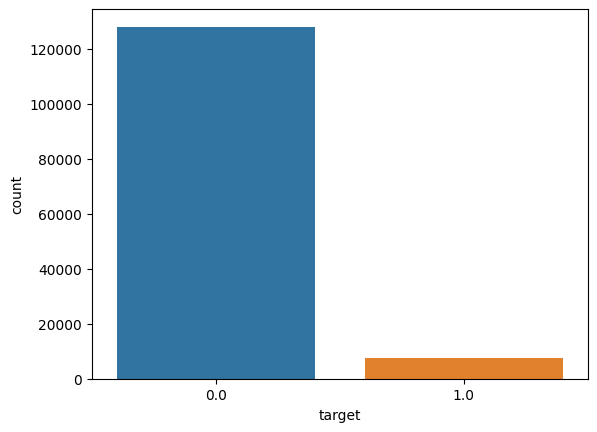

In [46]:
sns.countplot(x='target', data=df)
plt.show()

From this we can see that we are dealing with an imballaced data set

In [179]:
df['target'].value_counts(normalize=True)

target
0.0    0.944159
1.0    0.055841
Name: proportion, dtype: float64

### Train Test Split

In [47]:
X = df.drop(columns=['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RSEED, stratify = y)

### EDA

In [48]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108394 entries, 78888 to 106300
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         108394 non-null  int64  
 1   client_catg                     108394 non-null  int64  
 2   region                          108394 non-null  int64  
 3   Bill_Count                      108394 non-null  int64  
 4   creation_day                    108394 non-null  int64  
 5   creation_month                  108394 non-null  int64  
 6   creation_year                   108394 non-null  int64  
 7   avg_frequency_of_bills_in_days  108394 non-null  float64
 8   single_bill_client              108394 non-null  int64  
 9   tarif_type_mode                 108394 non-null  int64  
 10  counter_coefficient_mode        108394 non-null  int64  
 11  counter_type_mode               108394 non-null  object 
 12  reading_remarque_

In [49]:
# train dataframe shape
X_train.shape, y_train.shape

((108394, 24), (108394,))

In [50]:
# test dataframe shape
X_test.shape, y_test.shape

((27099, 24), (27099,))

In [51]:
y_train.value_counts(normalize=True)

target
0.0    0.944157
1.0    0.055843
Name: proportion, dtype: float64

In [52]:
y_test.value_counts(normalize=True)

target
0.0    0.944168
1.0    0.055832
Name: proportion, dtype: float64

In [53]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,108394.0,63.512510,3.353805,60.0,62.000000,62.000000,69.000000,69.000000
client_catg,108394.0,11.508598,4.406832,11.0,11.000000,11.000000,11.000000,51.000000
region,108394.0,206.278087,104.224262,101.0,103.000000,107.000000,307.000000,399.000000
Bill_Count,108394.0,33.051562,26.046356,1.0,10.000000,30.000000,50.000000,439.000000
creation_day,108394.0,17.487933,8.692855,1.0,10.000000,18.000000,25.000000,31.000000
creation_month,108394.0,7.280062,3.522409,1.0,4.000000,8.000000,11.000000,12.000000
creation_year,108394.0,2002.155202,11.579410,1977.0,1993.000000,2005.000000,2012.000000,2019.000000
avg_frequency_of_bills_in_days,108394.0,121.183944,86.476755,0.0,71.024390,117.612903,140.822193,3518.000000
single_bill_client,108394.0,0.030924,0.173113,0.0,0.000000,0.000000,0.000000,1.000000
tarif_type_mode,108394.0,12.888970,7.320741,9.0,11.000000,11.000000,11.000000,45.000000


In [54]:
X_train.isnull().sum()

disrict                              0
client_catg                          0
region                               0
Bill_Count                           0
creation_day                         0
creation_month                       0
creation_year                        0
avg_frequency_of_bills_in_days       0
single_bill_client                   0
tarif_type_mode                      0
counter_coefficient_mode             0
counter_type_mode                    0
reading_remarque_min                 0
reading_remarque_mode                0
consommation_level_1_mean            0
consommation_level_1_std          3352
consommation_level_2_mean            0
consommation_level_2_std          3352
consommation_level_3_mean            0
consommation_level_3_std          3352
consommation_level_4_mean            0
consommation_level_4_std          3352
diff_index_mean                      0
diff_index_std                    3352
dtype: int64

In [55]:
X_train = X_train.fillna(0)
X_train.isnull().sum()

disrict                           0
client_catg                       0
region                            0
Bill_Count                        0
creation_day                      0
creation_month                    0
creation_year                     0
avg_frequency_of_bills_in_days    0
single_bill_client                0
tarif_type_mode                   0
counter_coefficient_mode          0
counter_type_mode                 0
reading_remarque_min              0
reading_remarque_mode             0
consommation_level_1_mean         0
consommation_level_1_std          0
consommation_level_2_mean         0
consommation_level_2_std          0
consommation_level_3_mean         0
consommation_level_3_std          0
consommation_level_4_mean         0
consommation_level_4_std          0
diff_index_mean                   0
diff_index_std                    0
dtype: int64

In [56]:
X_test = X_test.fillna(0)
X_test.isnull().sum()

disrict                           0
client_catg                       0
region                            0
Bill_Count                        0
creation_day                      0
creation_month                    0
creation_year                     0
avg_frequency_of_bills_in_days    0
single_bill_client                0
tarif_type_mode                   0
counter_coefficient_mode          0
counter_type_mode                 0
reading_remarque_min              0
reading_remarque_mode             0
consommation_level_1_mean         0
consommation_level_1_std          0
consommation_level_2_mean         0
consommation_level_2_std          0
consommation_level_3_mean         0
consommation_level_3_std          0
consommation_level_4_mean         0
consommation_level_4_std          0
diff_index_mean                   0
diff_index_std                    0
dtype: int64

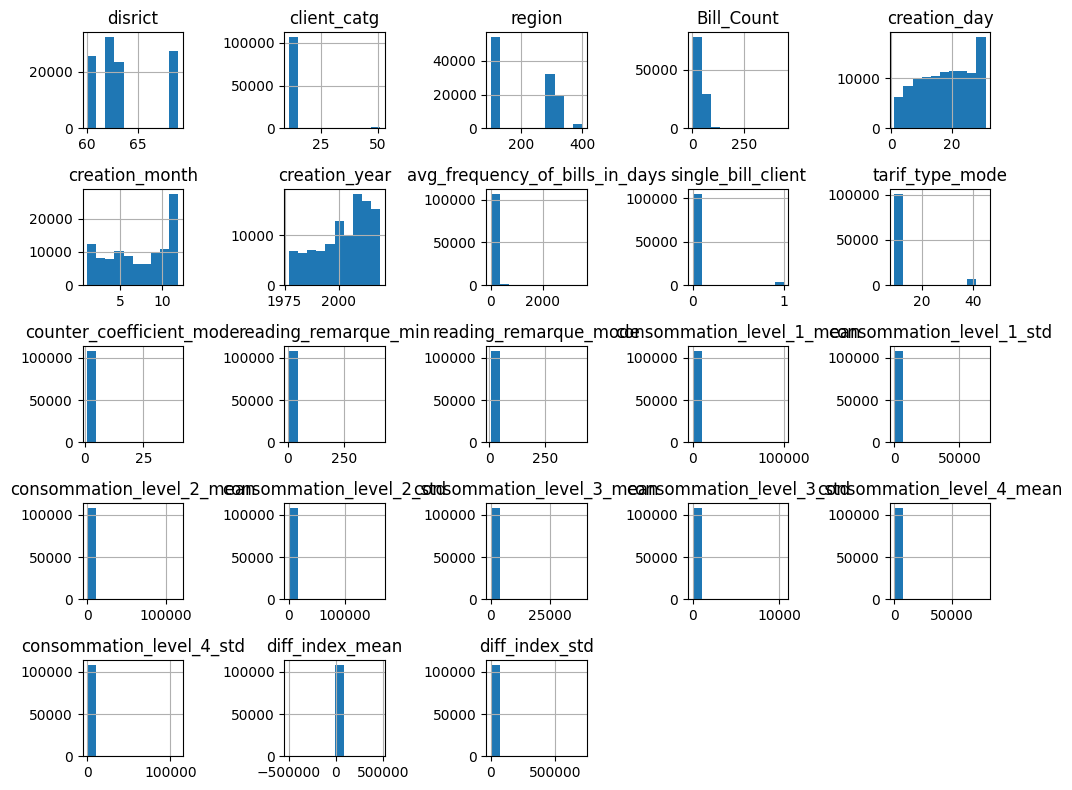

In [57]:
X_train.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

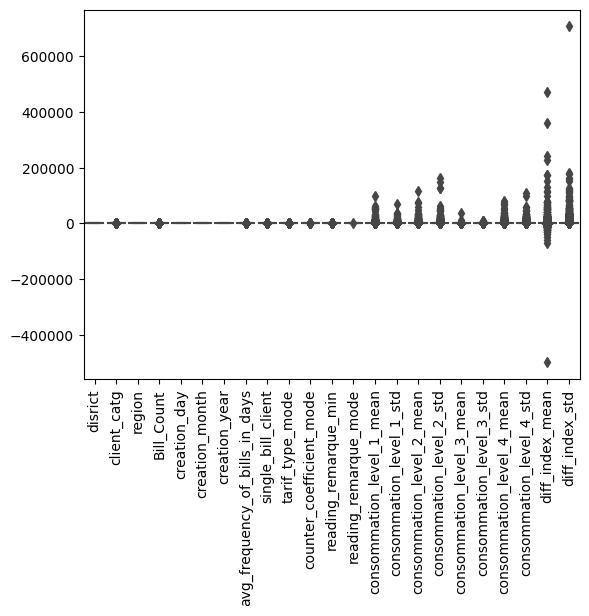

In [58]:
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [59]:
X_train.columns

Index(['disrict', 'client_catg', 'region', 'Bill_Count', 'creation_day',
       'creation_month', 'creation_year', 'avg_frequency_of_bills_in_days',
       'single_bill_client', 'tarif_type_mode', 'counter_coefficient_mode',
       'counter_type_mode', 'reading_remarque_min', 'reading_remarque_mode',
       'consommation_level_1_mean', 'consommation_level_1_std',
       'consommation_level_2_mean', 'consommation_level_2_std',
       'consommation_level_3_mean', 'consommation_level_3_std',
       'consommation_level_4_mean', 'consommation_level_4_std',
       'diff_index_mean', 'diff_index_std'],
      dtype='object')

### EDA for categorical variables

In [60]:
categorical_cols = [
    'disrict',
    'client_catg',
    'region',
    'tarif_type_mode',
    'counter_coefficient_mode',
    'counter_type_mode',
    'reading_remarque_min',
    'reading_remarque_mode',
    'single_bill_client'
]
categorical_data = X_train[categorical_cols]
categorical_data.head()

,disrict,client_catg,region,tarif_type_mode,counter_coefficient_mode,counter_type_mode,reading_remarque_min,reading_remarque_mode,single_bill_client
78888,69,11,104,11,1,ELEC,6,9,0
135126,62,11,304,11,1,ELEC,6,6,0
116929,60,11,101,11,1,ELEC,6,9,0
22992,62,11,309,11,1,ELEC,6,9,0
57992,60,11,101,11,1,ELEC,6,6,0


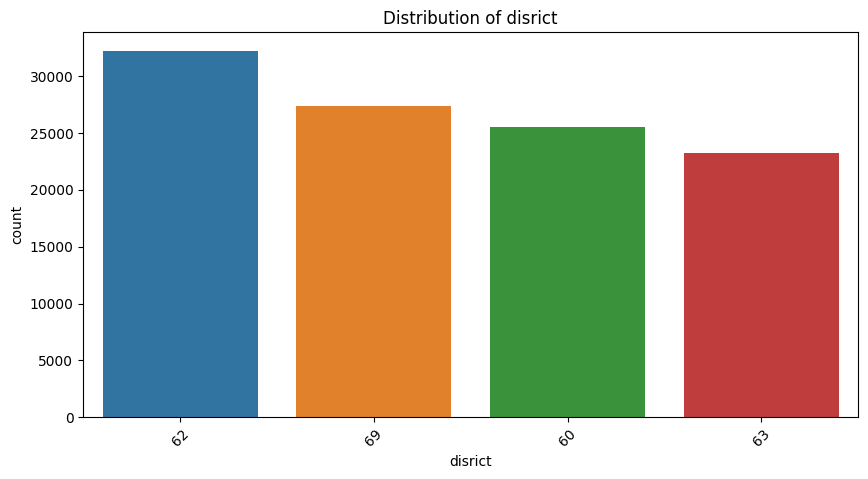

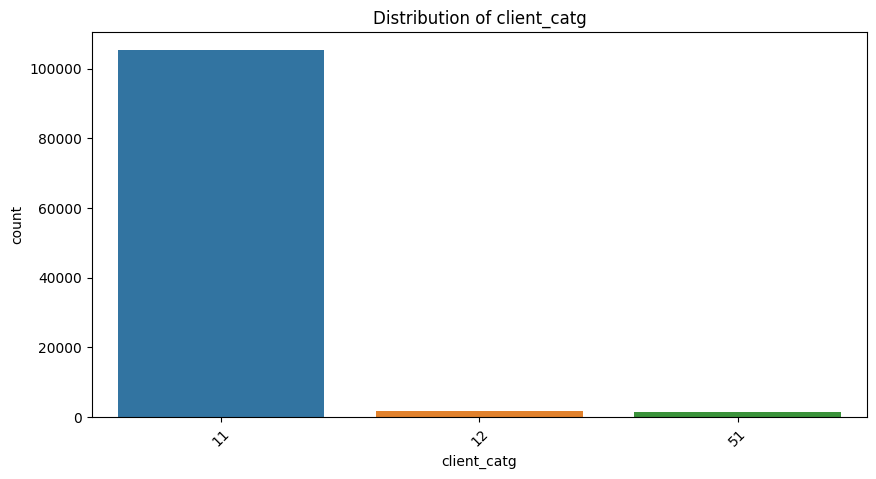

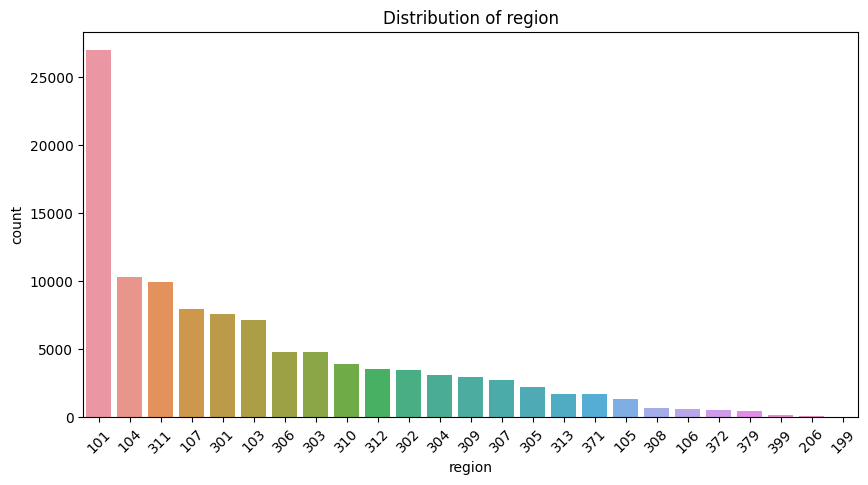

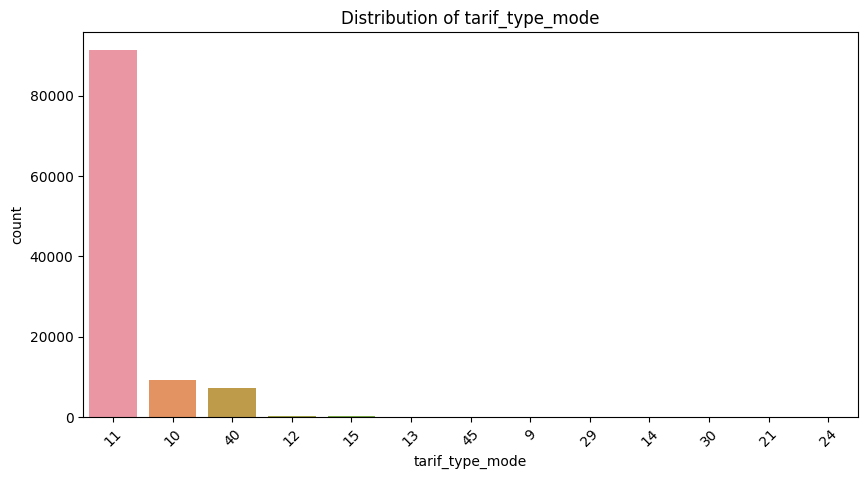

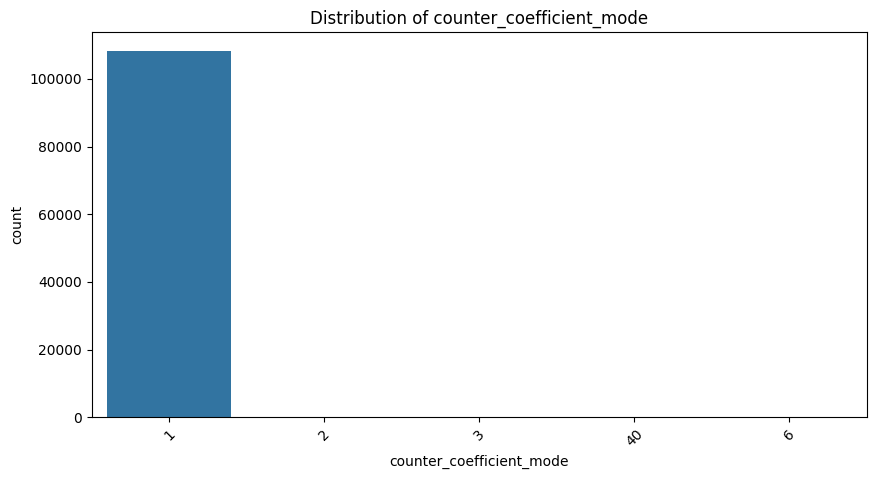

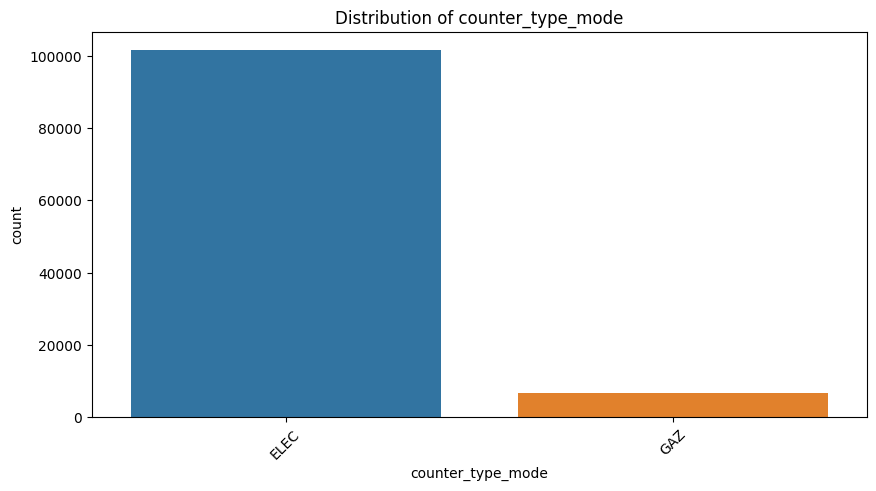

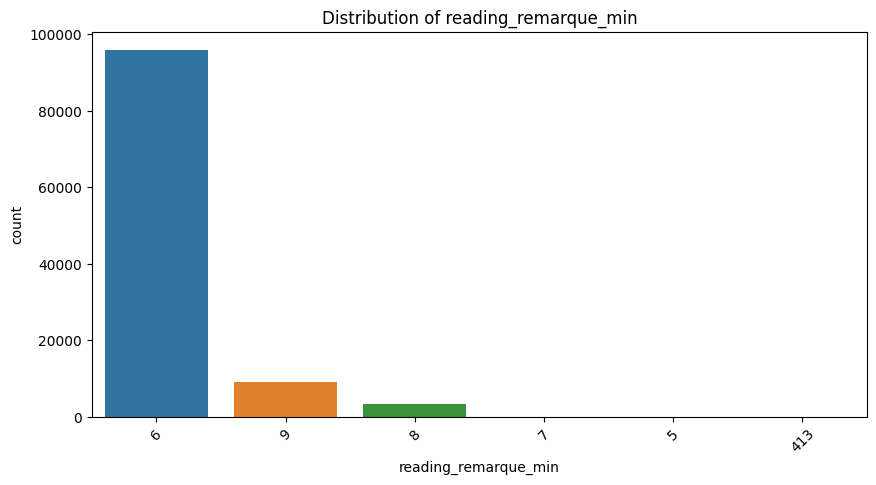

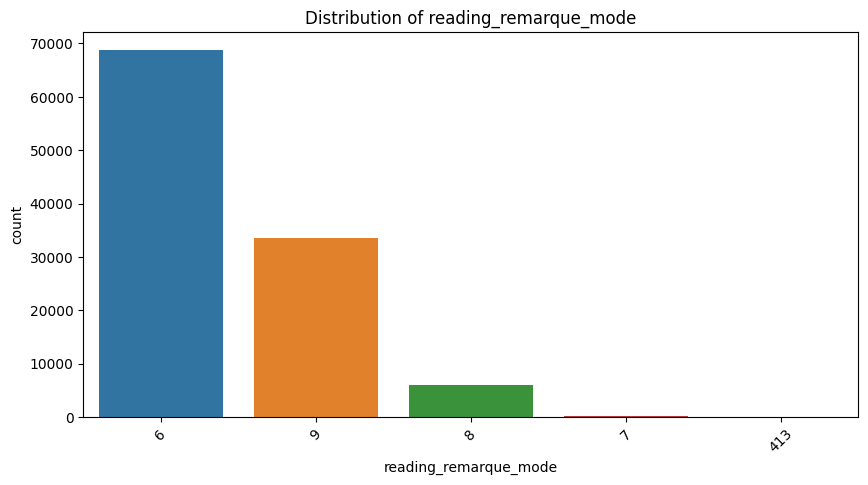

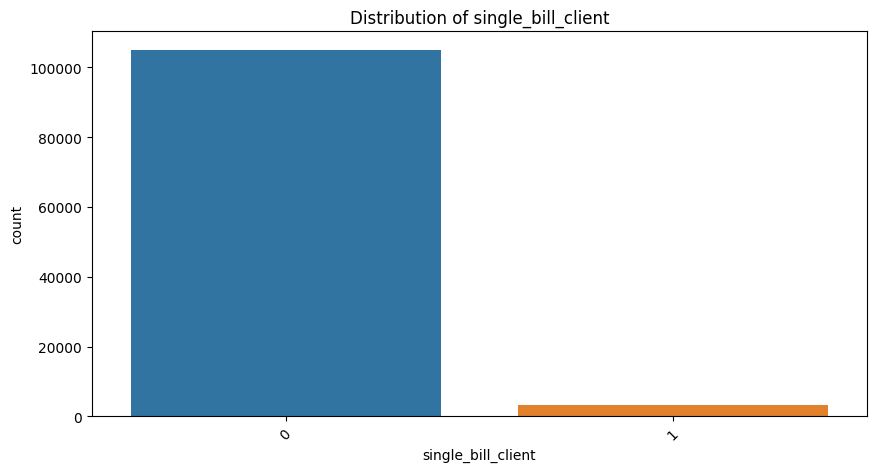

In [61]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=X_train, order=X_train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

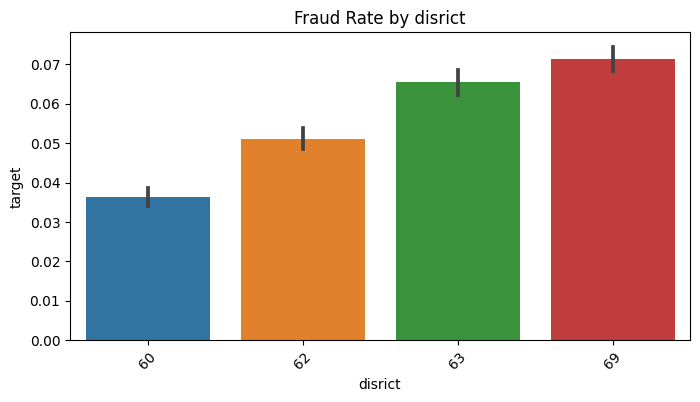

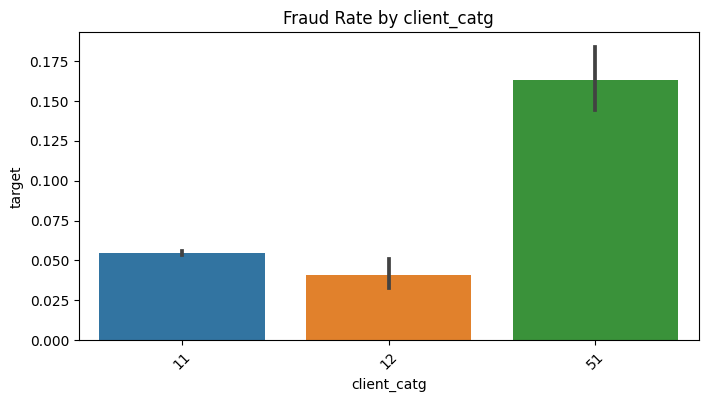

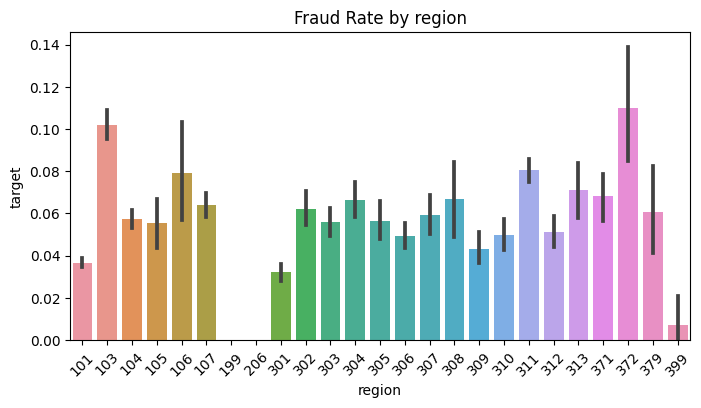

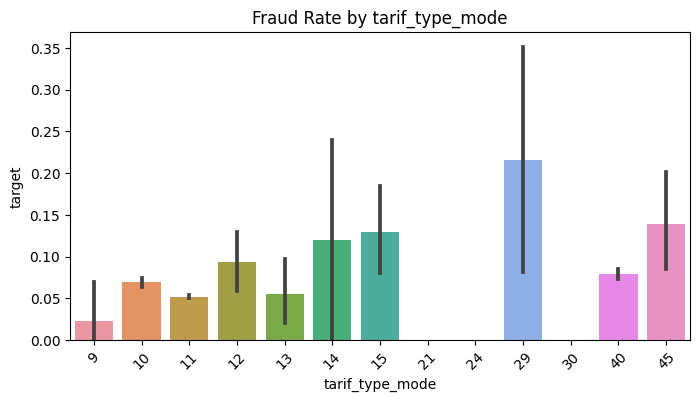

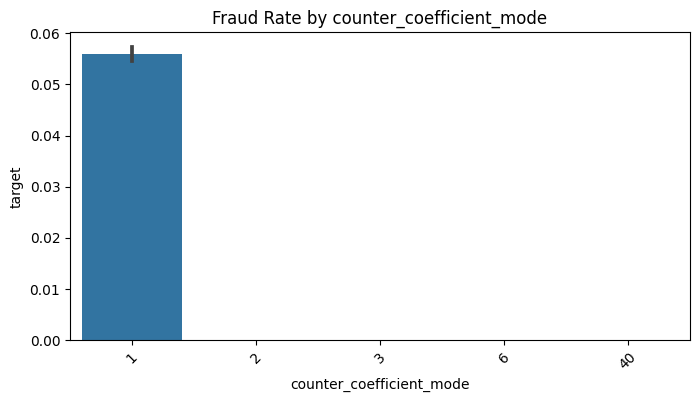

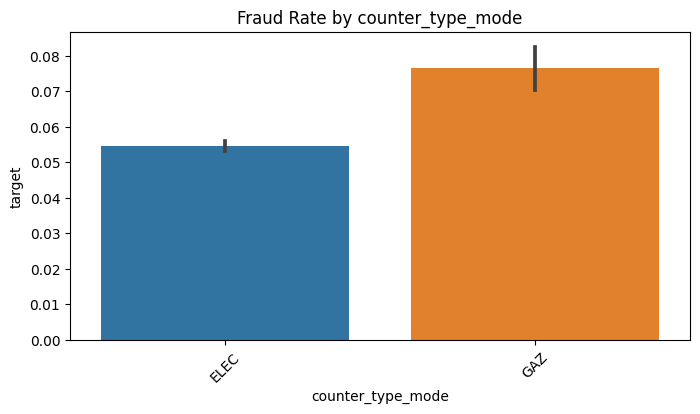

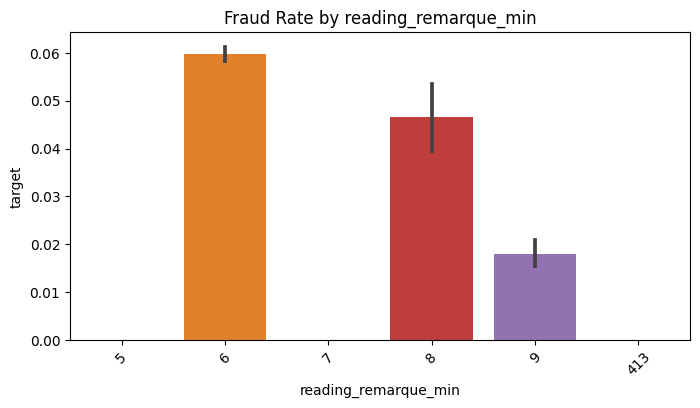

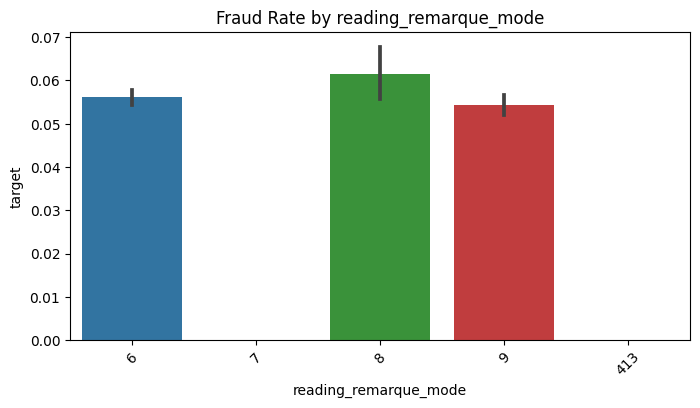

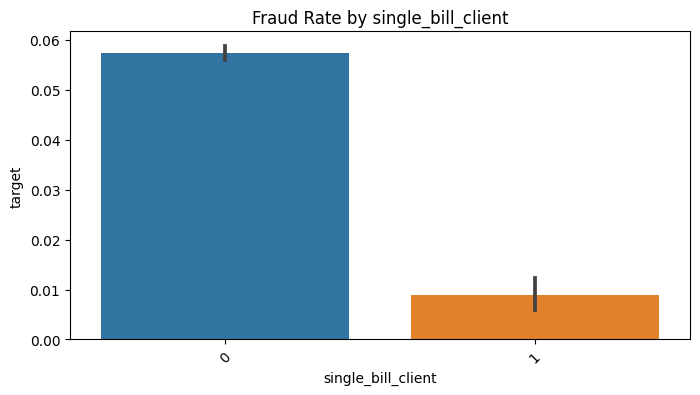

In [62]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=X_train, x=col, y=y_train)  # Replace `y_train` with your target variable
    plt.title(f'Fraud Rate by {col}')
    plt.xticks(rotation=45)
    plt.show()

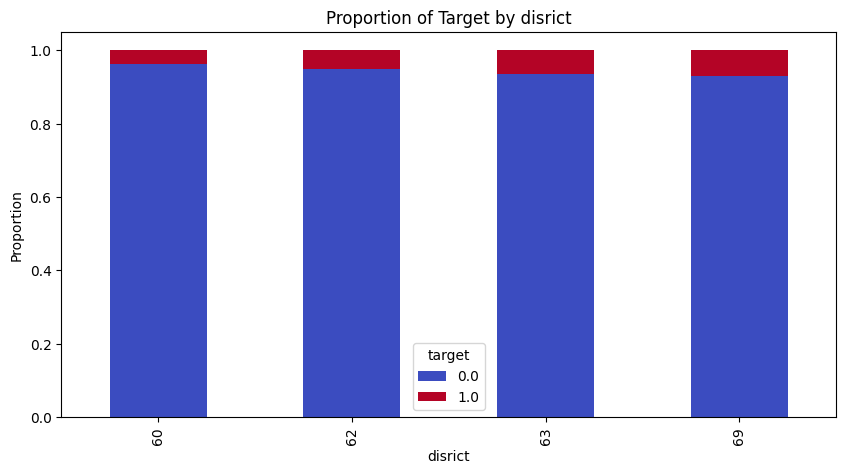

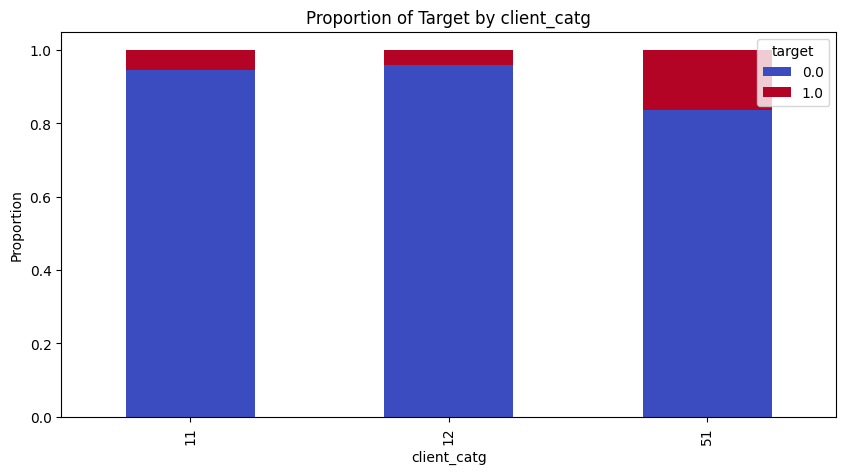

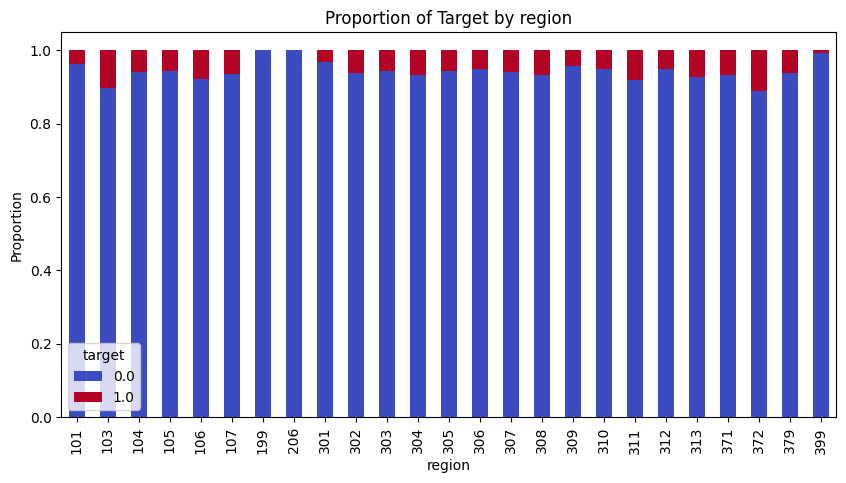

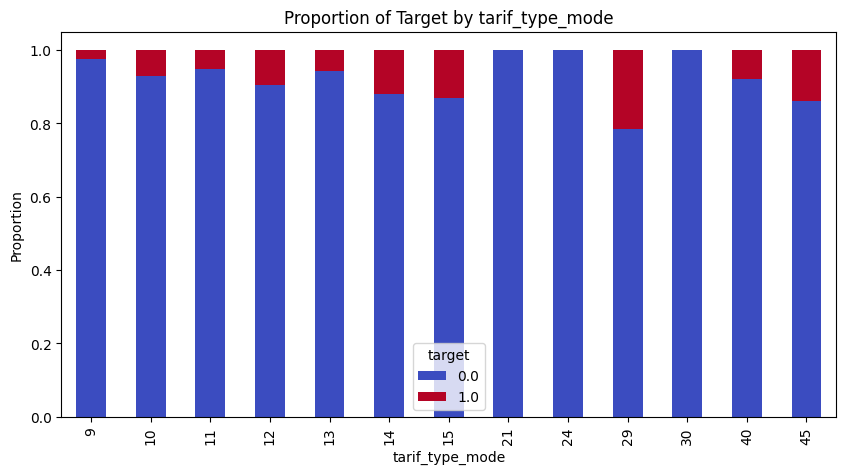

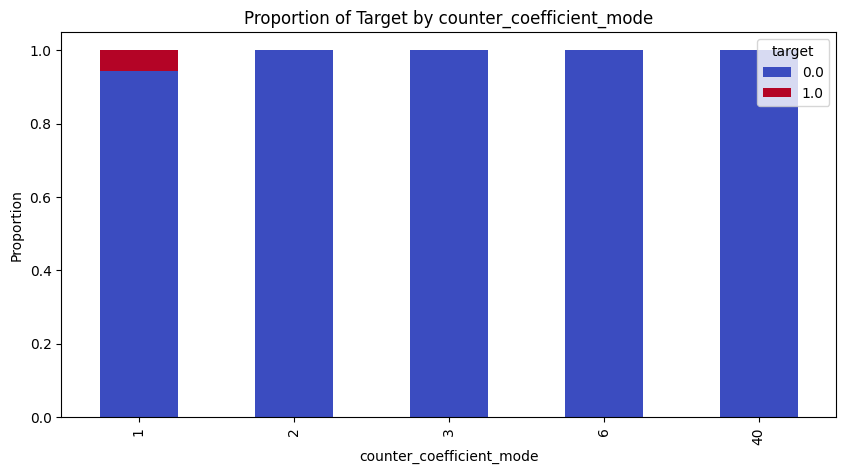

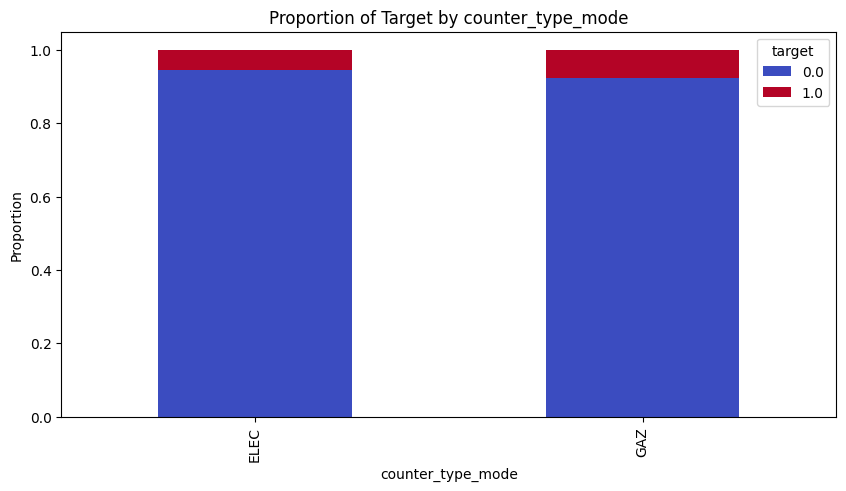

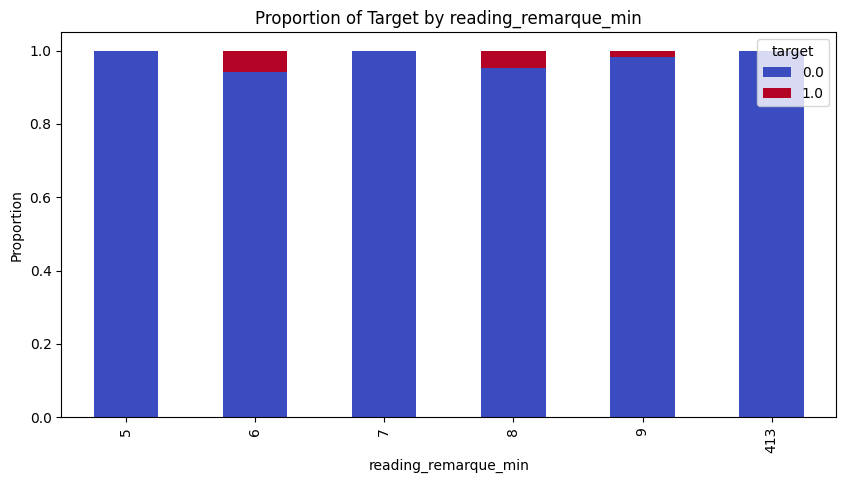

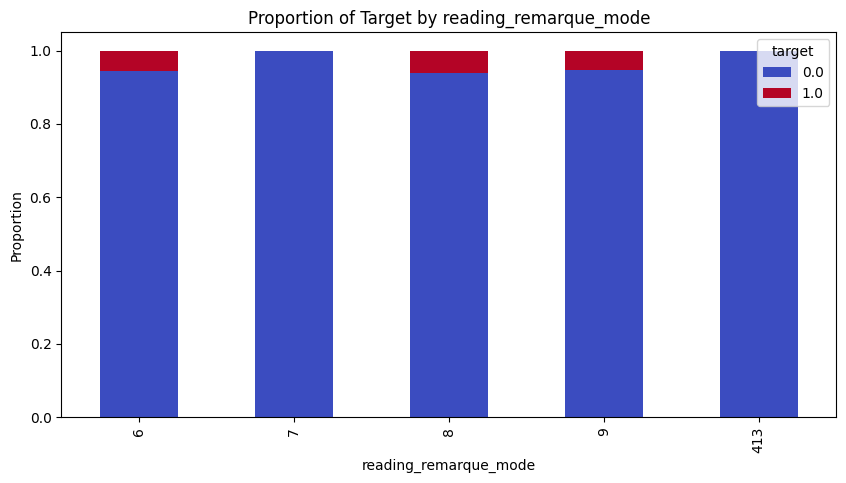

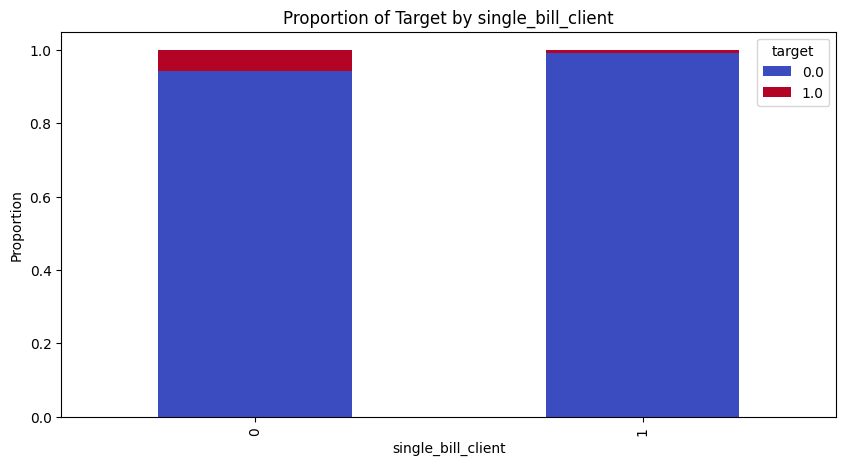

In [63]:
#X_train['target'] = y_train  # Combine for analysis

for col in categorical_cols:
    cross_tab = pd.crosstab(X_train[col], y_train, normalize='index')
    cross_tab.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='coolwarm')
    plt.title(f"Proportion of Target by {col}")
    plt.ylabel('Proportion')
    plt.show()

# Drop the target column afterward if modifying X_train directly
#X_train.drop('target', axis=1, inplace=True)

In [64]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(X_train[col], y_train)
    chi2_stat, p_value, dof, _ = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {col}:\nChi2 Statistic: {chi2_stat}, P-value: {p_value}\n")

Chi-Square Test for disrict:
Chi2 Statistic: 363.47880306062837, P-value: 1.7986651187661604e-78

Chi-Square Test for client_catg:
Chi2 Statistic: 299.6406669137208, P-value: 8.587285514392814e-66

Chi-Square Test for region:
Chi2 Statistic: 773.5757436782771, P-value: 7.82895227327123e-148

Chi-Square Test for tarif_type_mode:
Chi2 Statistic: 193.29134195442882, P-value: 7.88618400613391e-35

Chi-Square Test for counter_coefficient_mode:
Chi2 Statistic: 1.5973238426389806, P-value: 0.8092730447511967

Chi-Square Test for counter_type_mode:
Chi2 Statistic: 58.16058873527125, P-value: 2.415704313800255e-14

Chi-Square Test for reading_remarque_min:
Chi2 Statistic: 284.077182770844, P-value: 2.648348431472264e-59

Chi-Square Test for reading_remarque_mode:
Chi2 Statistic: 11.320178365279864, P-value: 0.023191804723538986

Chi-Square Test for single_bill_client:
Chi2 Statistic: 143.343967519847, P-value: 4.943387641042145e-33



In [65]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 != col2:
            score = cramers_v(X_train[col1], X_train[col2])
            print(f"Cramér's V between {col1} and {col2}: {score}")

Cramér's V between disrict and client_catg: 0.03622504858712263
Cramér's V between disrict and region: 0.9807442004564256
Cramér's V between disrict and tarif_type_mode: 0.12274110527997041
Cramér's V between disrict and counter_coefficient_mode: 0.013980396231567839
Cramér's V between disrict and counter_type_mode: 0.0888477535647628
Cramér's V between disrict and reading_remarque_min: 0.04423140761936356
Cramér's V between disrict and reading_remarque_mode: 0.07158068392709756
Cramér's V between disrict and single_bill_client: 0.04018479345811296
Cramér's V between client_catg and disrict: 0.03622504858712263
Cramér's V between client_catg and region: 0.05736314067747833
Cramér's V between client_catg and tarif_type_mode: 0.09253023278186086
Cramér's V between client_catg and counter_coefficient_mode: 0.04918535889820891
Cramér's V between client_catg and counter_type_mode: 0.016207847204244515
Cramér's V between client_catg and reading_remarque_min: 0.034383096779306246
Cramér's V b

In [66]:
for col in categorical_cols:
    unique_count = X_train[col].nunique()
    print(f"{col}: {unique_count} unique values")

disrict: 4 unique values
client_catg: 3 unique values
region: 25 unique values
tarif_type_mode: 13 unique values
counter_coefficient_mode: 5 unique values
counter_type_mode: 2 unique values
reading_remarque_min: 6 unique values
reading_remarque_mode: 5 unique values
single_bill_client: 2 unique values


In [67]:
for col in categorical_cols:
    print(f"Unique values in {col}:\n{X_train[col].unique()}\n")

Unique values in disrict:
[69 62 60 63]

Unique values in client_catg:
[11 51 12]

Unique values in region:
[104 304 101 309 303 107 306 302 103 310 301 311 307 379 305 312 106 313
 308 372 105 371 399 206 199]

Unique values in tarif_type_mode:
[11 10 40 15 13 12 45  9 29 30 14 21 24]

Unique values in counter_coefficient_mode:
[ 1  2 40  3  6]

Unique values in counter_type_mode:
['ELEC' 'GAZ']

Unique values in reading_remarque_min:
[  6   8   9   7   5 413]

Unique values in reading_remarque_mode:
[  9   6   8   7 413]

Unique values in single_bill_client:
[0 1]



### EDA on Numerical Data

In [68]:
numeric_cols = ['Bill_Count', 'creation_day', 'creation_month', 
                'creation_year', 'avg_frequency_of_bills_in_days',
                'consommation_level_1_mean', 'consommation_level_1_std', 
                'consommation_level_2_mean', 'consommation_level_2_std', 
                'consommation_level_3_mean', 'consommation_level_3_std',
                'consommation_level_4_mean', 'consommation_level_4_std',
                'diff_index_mean', 'diff_index_std']


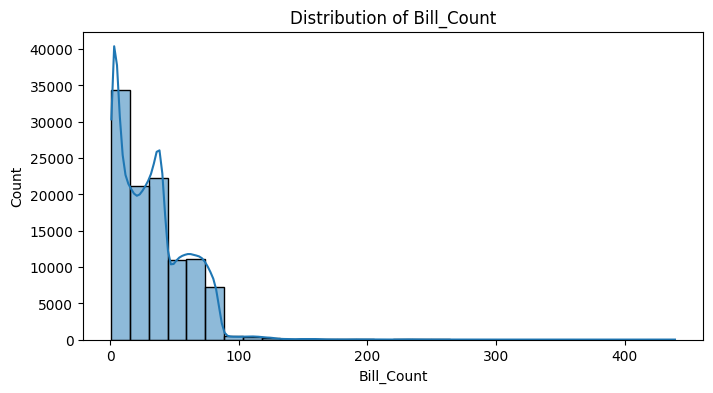

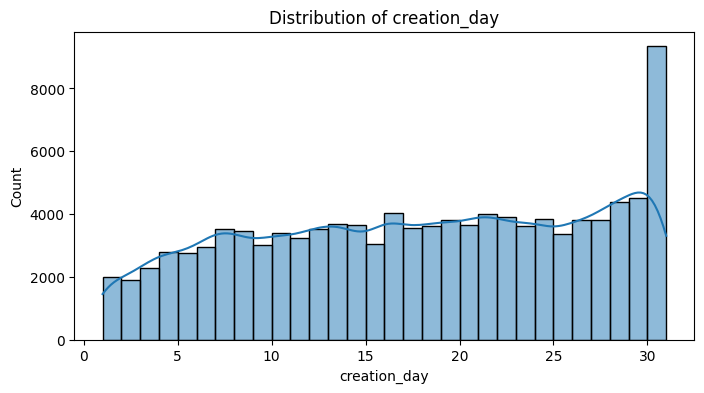

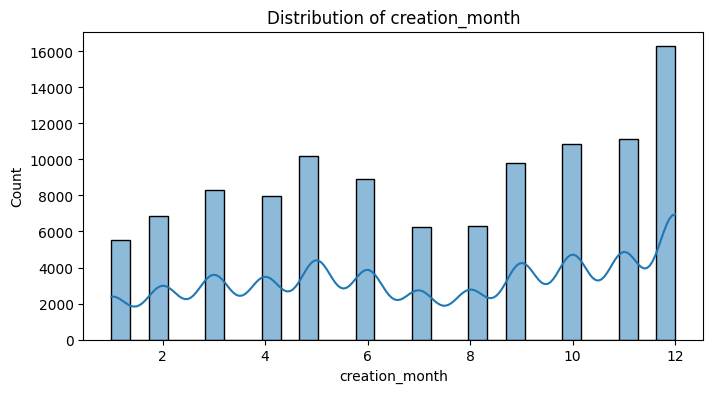

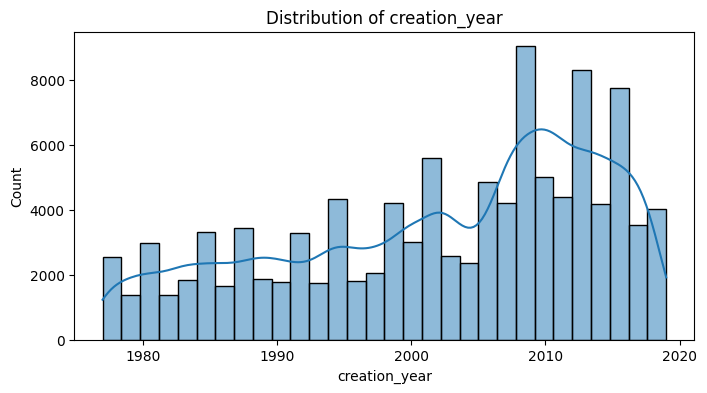

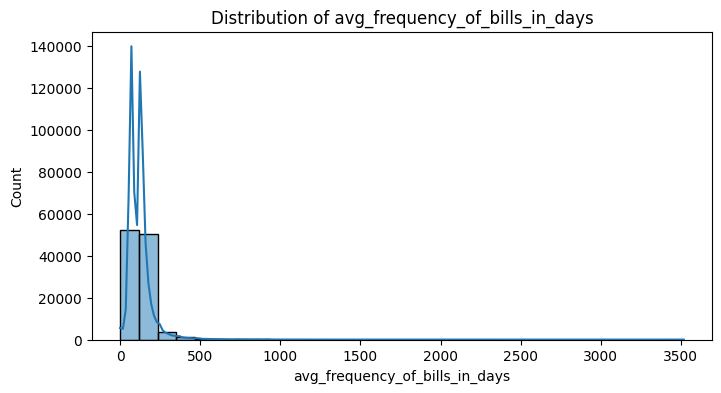

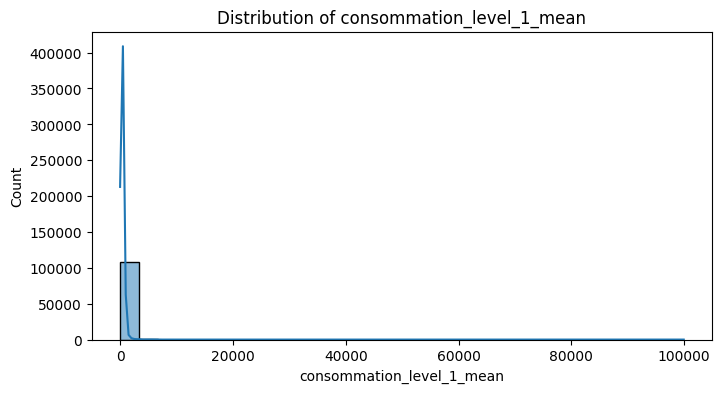

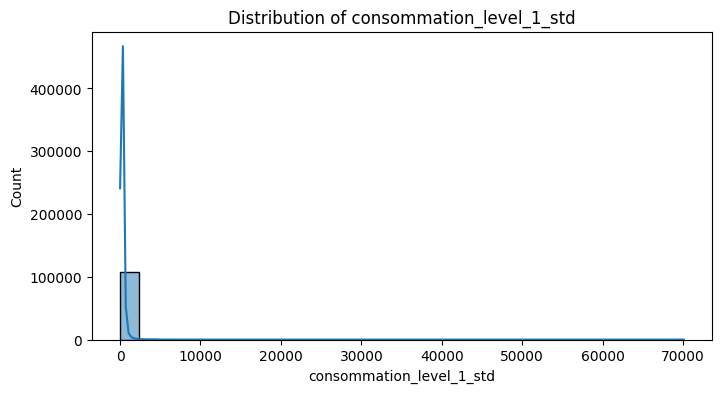

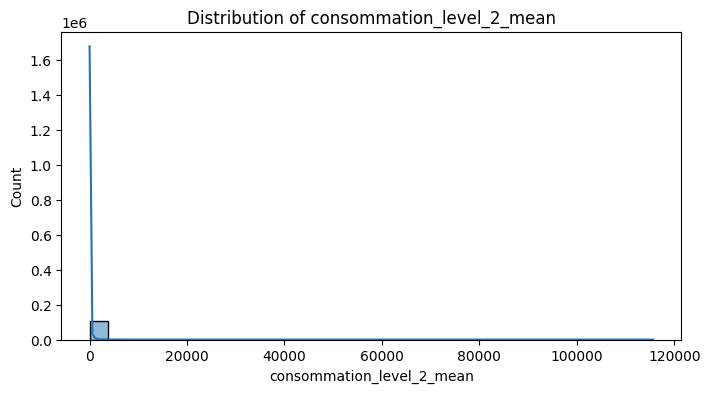

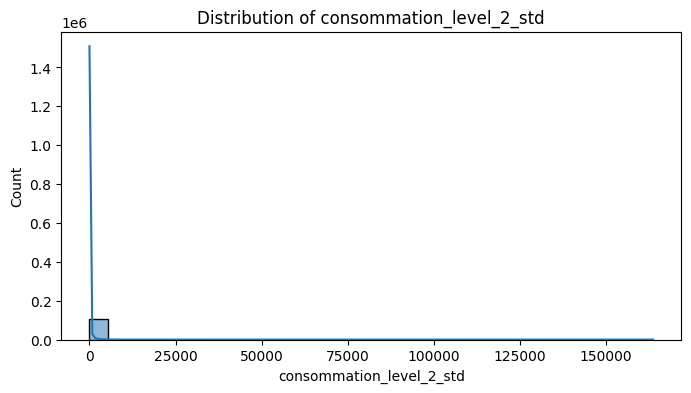

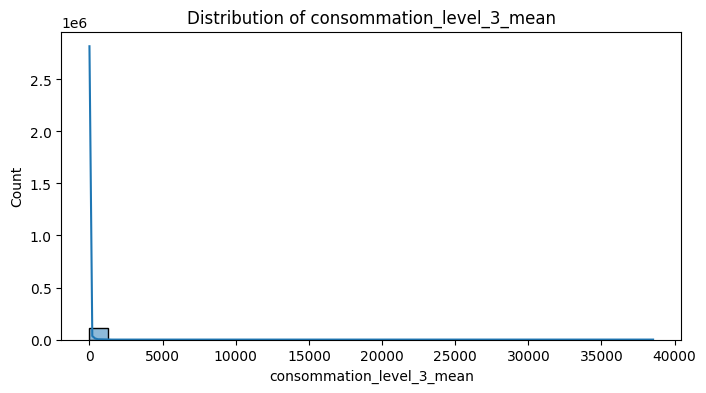

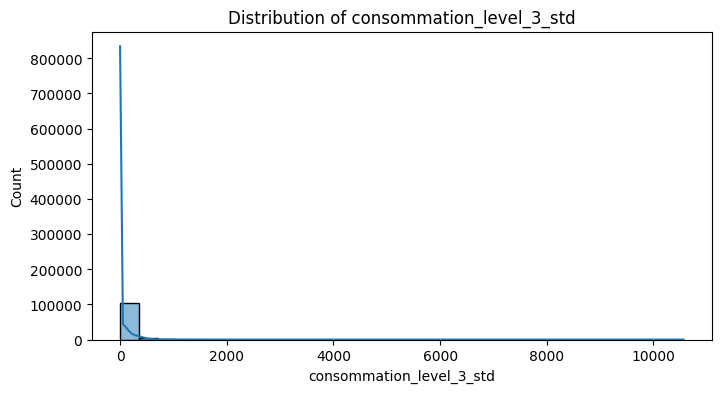

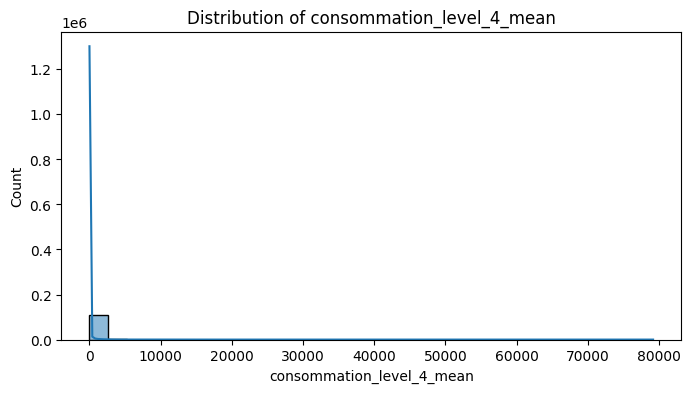

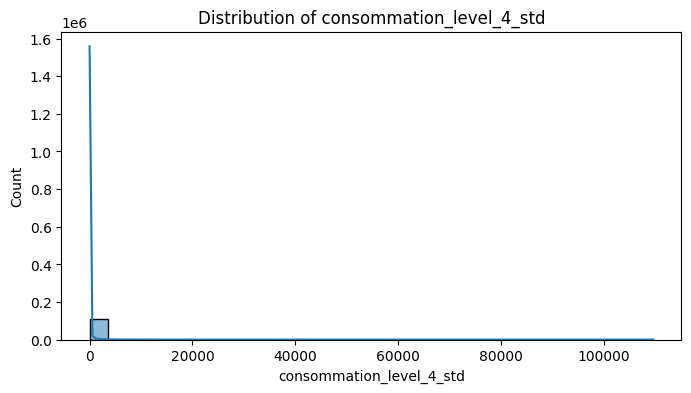

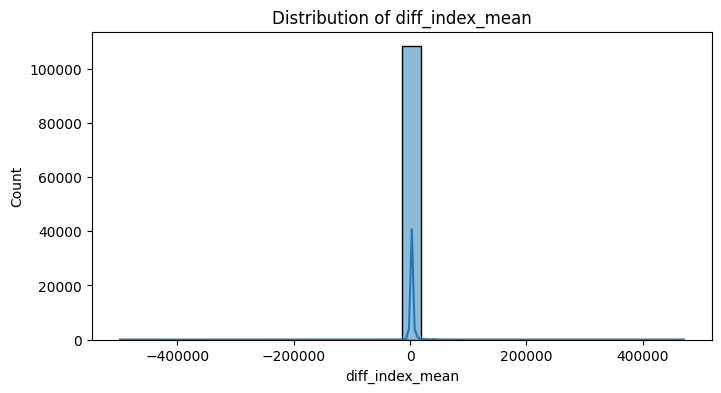

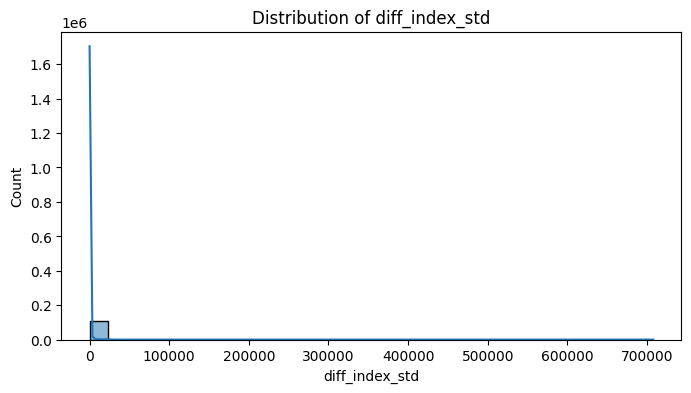

In [69]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

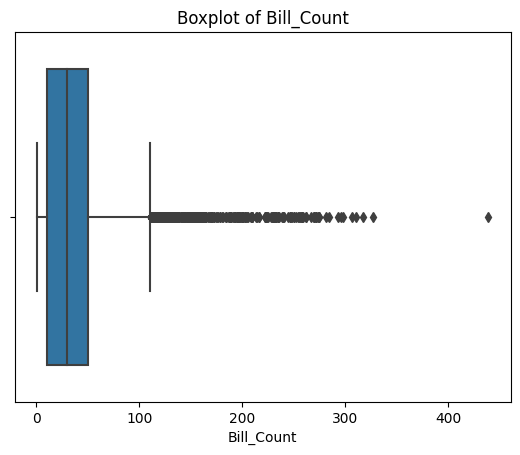

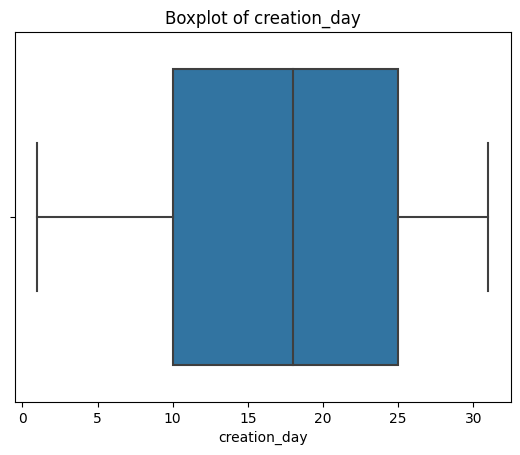

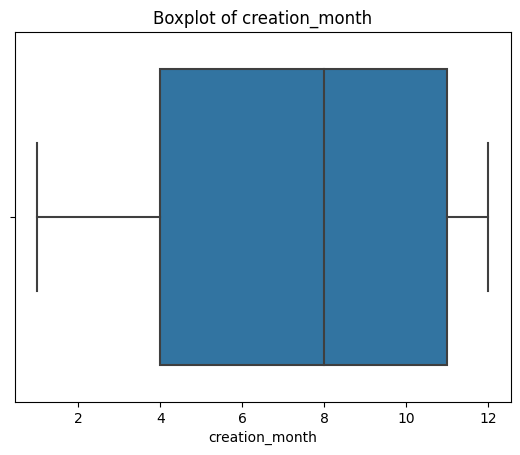

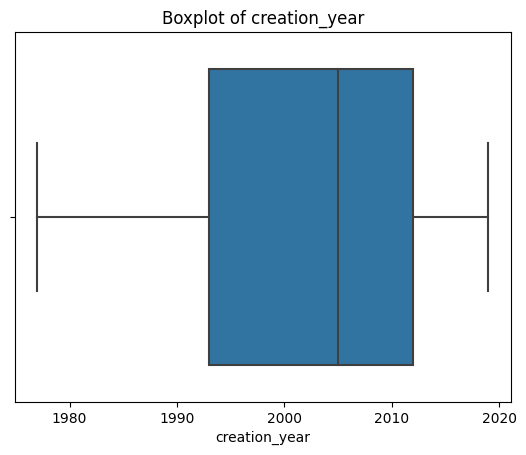

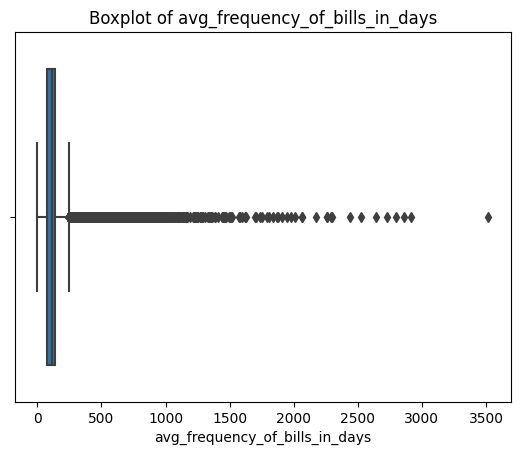

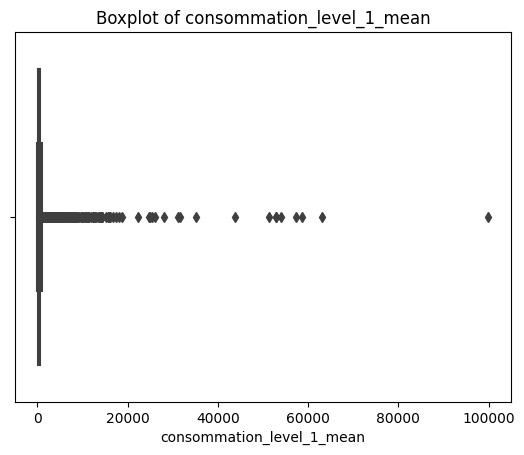

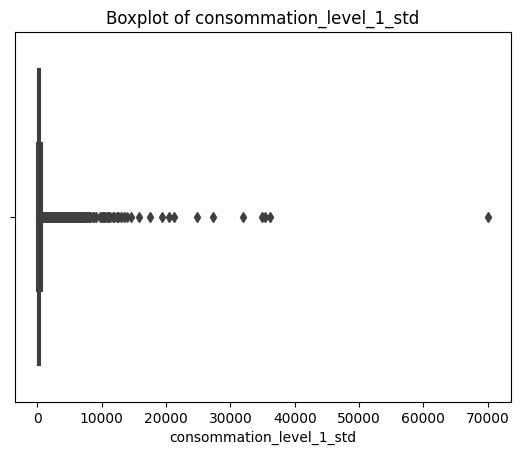

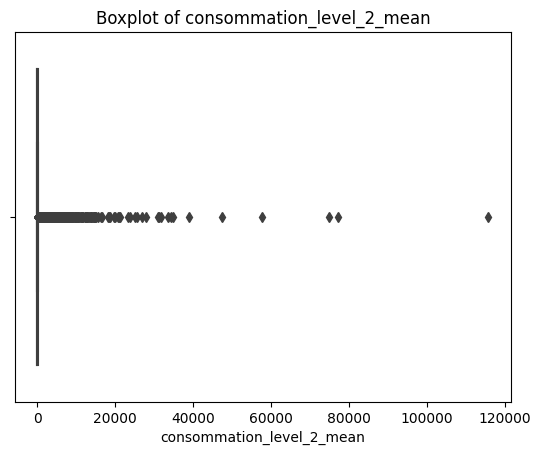

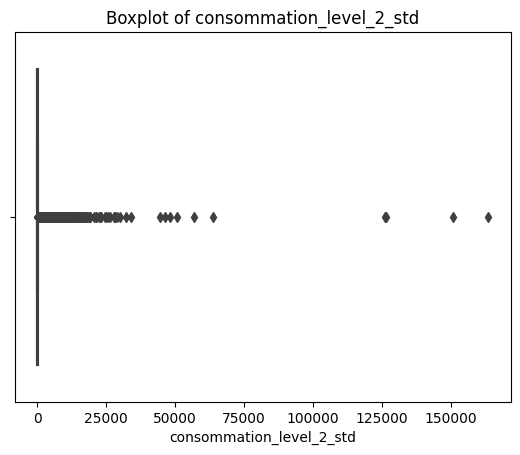

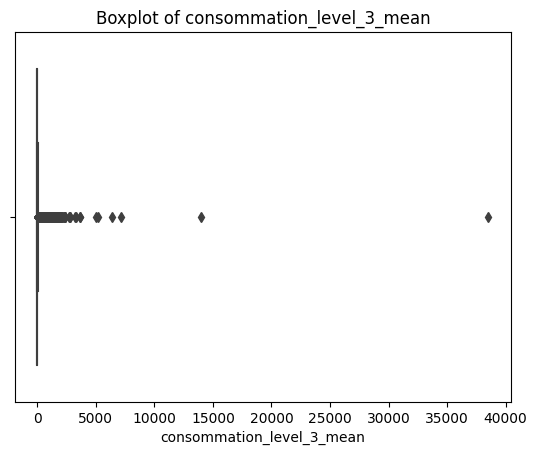

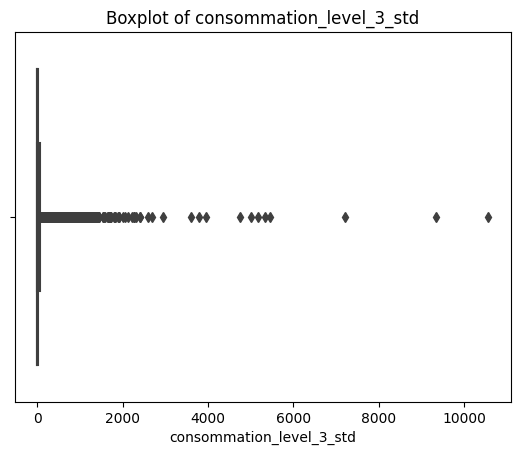

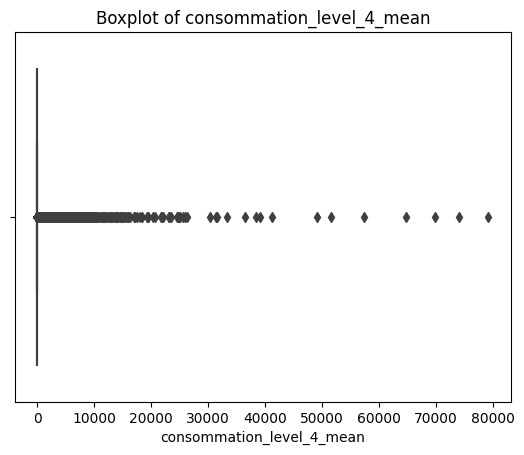

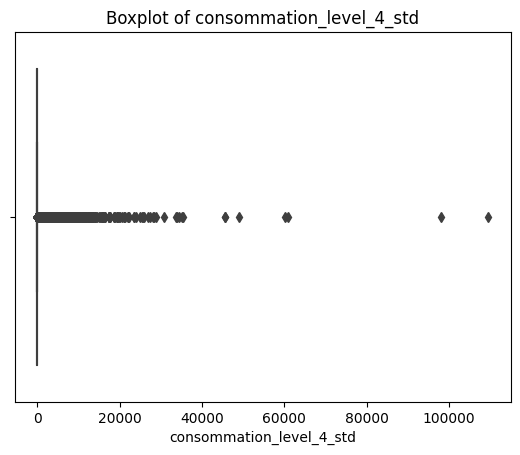

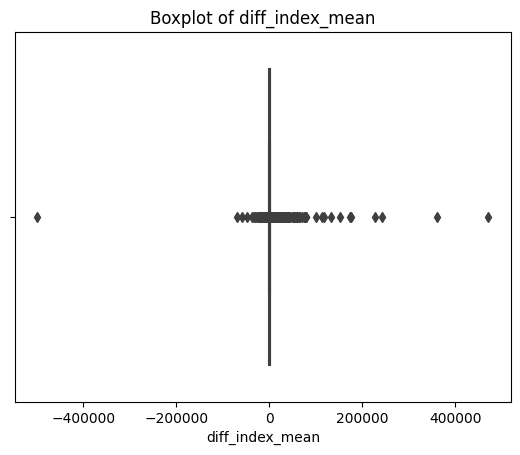

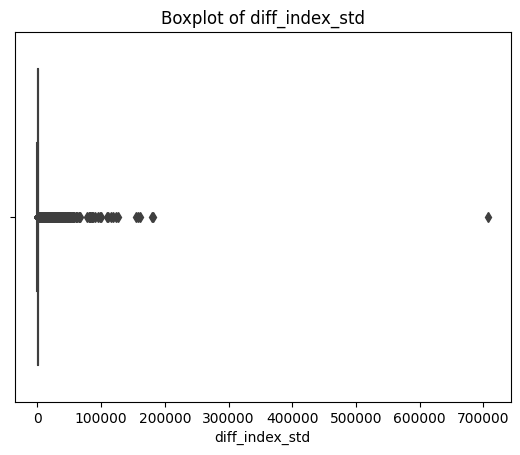

In [70]:
for col in numeric_cols:  
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Bill_Count
count    108394.000000
mean         33.051562
std          26.046356
min           1.000000
25%          10.000000
50%          30.000000
75%          50.000000
max         439.000000
Name: Bill_Count, dtype: float64


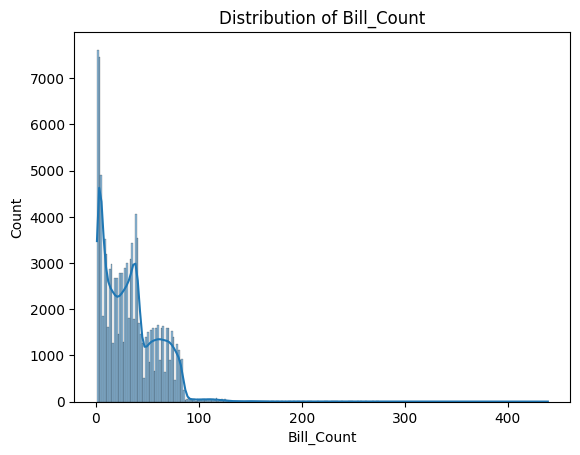

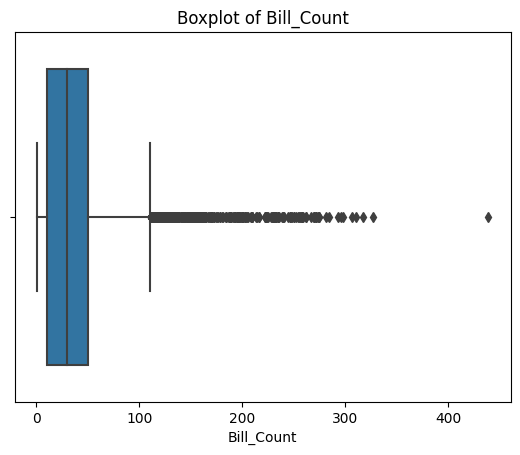

-----------------------------
creation_day
count    108394.000000
mean         17.487933
std           8.692855
min           1.000000
25%          10.000000
50%          18.000000
75%          25.000000
max          31.000000
Name: creation_day, dtype: float64


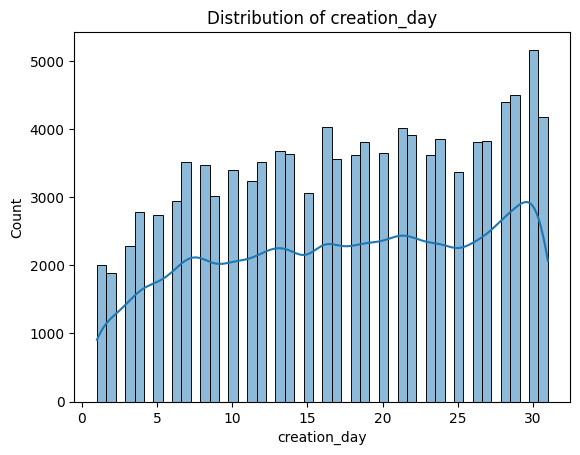

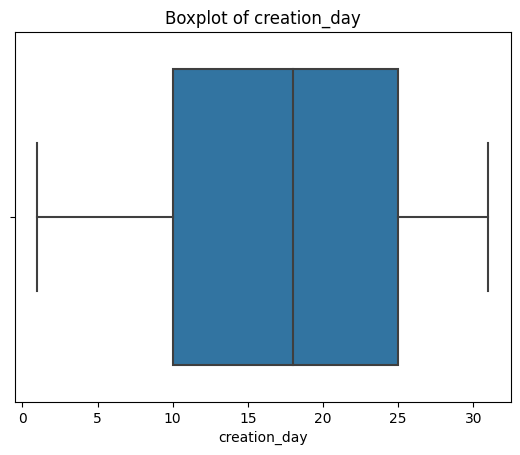

-----------------------------
creation_month
count    108394.000000
mean          7.280062
std           3.522409
min           1.000000
25%           4.000000
50%           8.000000
75%          11.000000
max          12.000000
Name: creation_month, dtype: float64


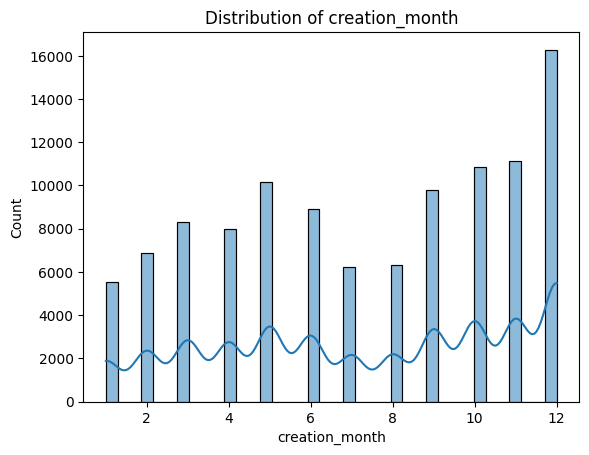

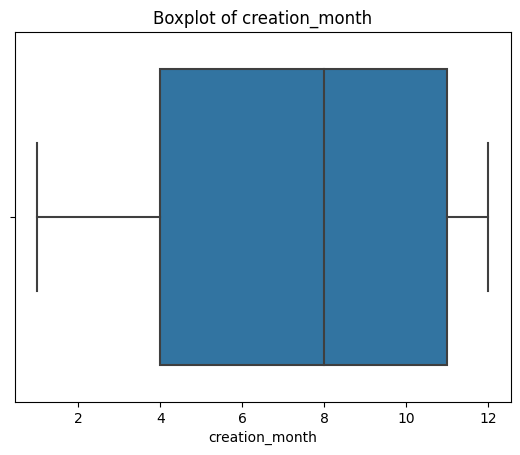

-----------------------------
creation_year
count    108394.000000
mean       2002.155202
std          11.579410
min        1977.000000
25%        1993.000000
50%        2005.000000
75%        2012.000000
max        2019.000000
Name: creation_year, dtype: float64


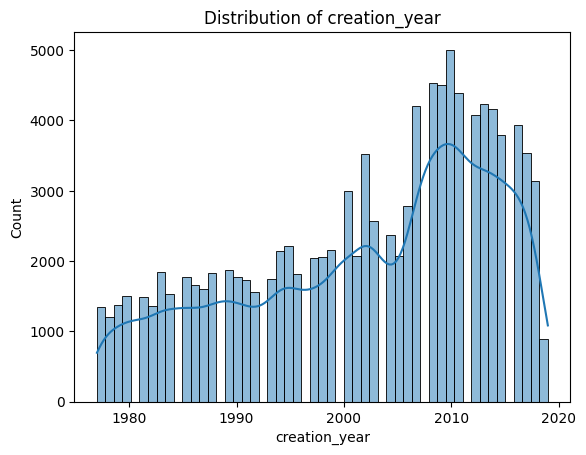

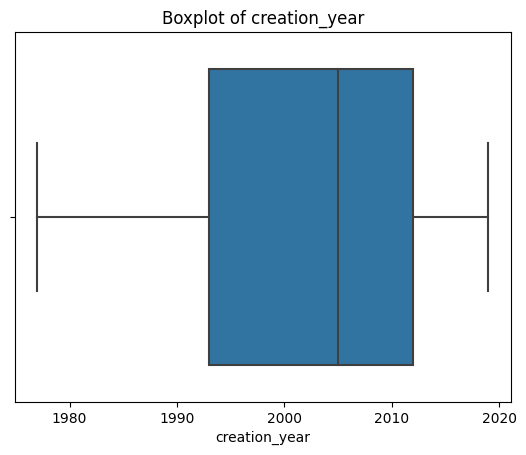

-----------------------------
avg_frequency_of_bills_in_days
count    108394.000000
mean        121.183944
std          86.476755
min           0.000000
25%          71.024390
50%         117.612903
75%         140.822193
max        3518.000000
Name: avg_frequency_of_bills_in_days, dtype: float64


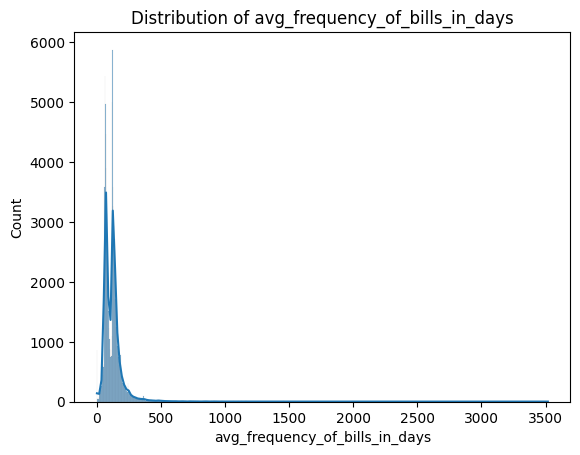

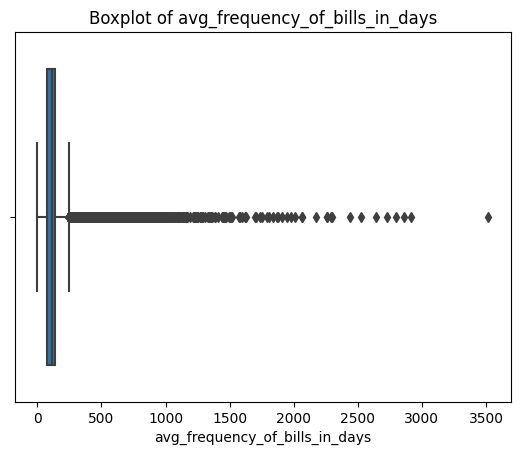

-----------------------------
consommation_level_1_mean
count    108394.000000
mean        431.665871
std         759.719564
min           0.000000
25%         215.500000
50%         355.470417
75%         541.238511
max       99920.000000
Name: consommation_level_1_mean, dtype: float64


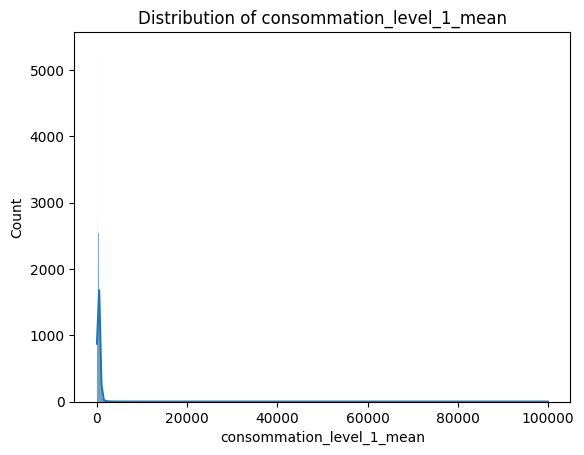

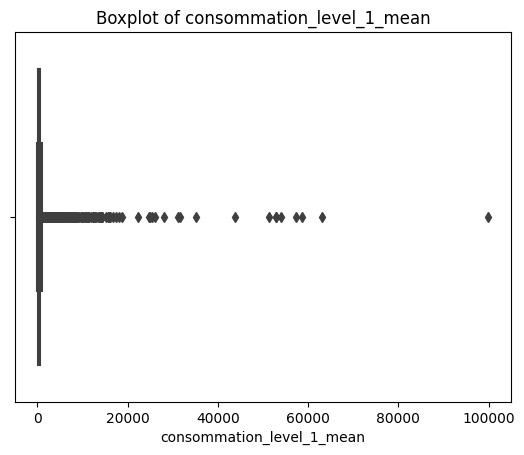

-----------------------------
consommation_level_1_std
count    108394.000000
mean        323.149035
std         502.082246
min           0.000000
25%         161.096399
50%         272.958851
75%         399.223009
max       70094.001474
Name: consommation_level_1_std, dtype: float64


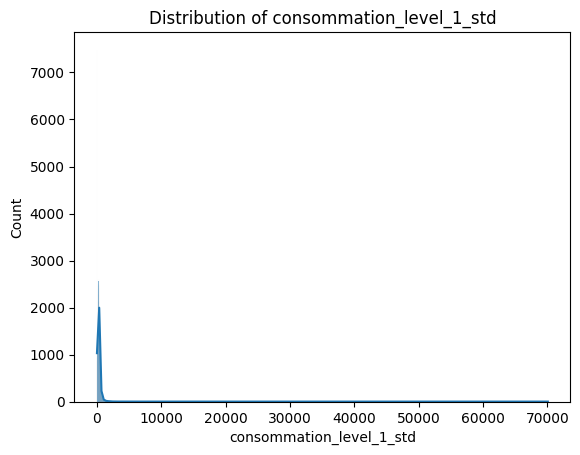

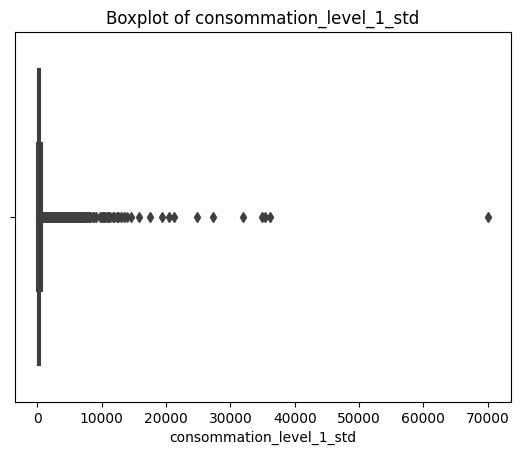

-----------------------------
consommation_level_2_mean
count    108394.000000
mean        116.620732
std         791.747611
min           0.000000
25%           0.000000
50%           4.967204
75%          63.500000
max      115683.000000
Name: consommation_level_2_mean, dtype: float64


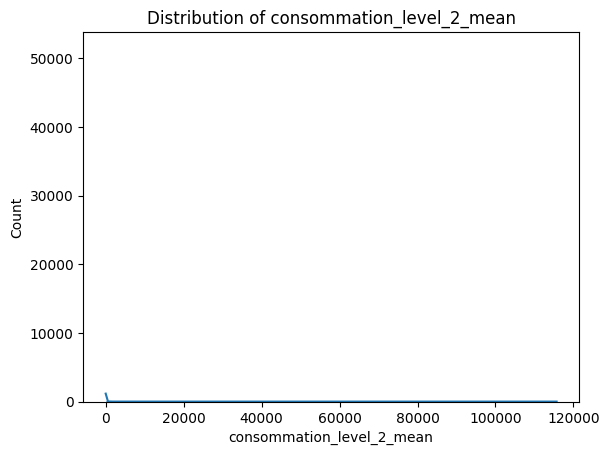

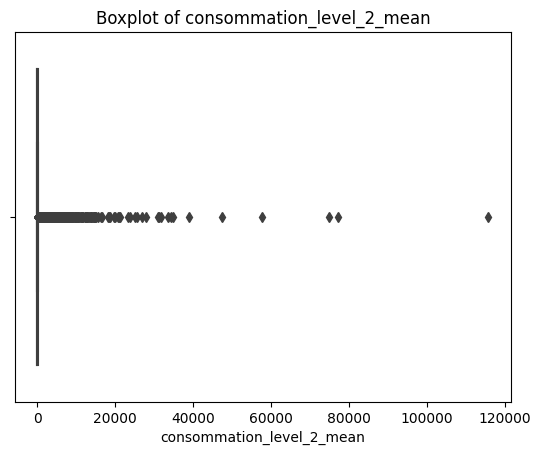

-----------------------------
consommation_level_2_std
count    108394.000000
mean        173.402600
std        1155.525734
min           0.000000
25%           0.000000
50%          24.104367
75%         141.421356
max      163705.093298
Name: consommation_level_2_std, dtype: float64


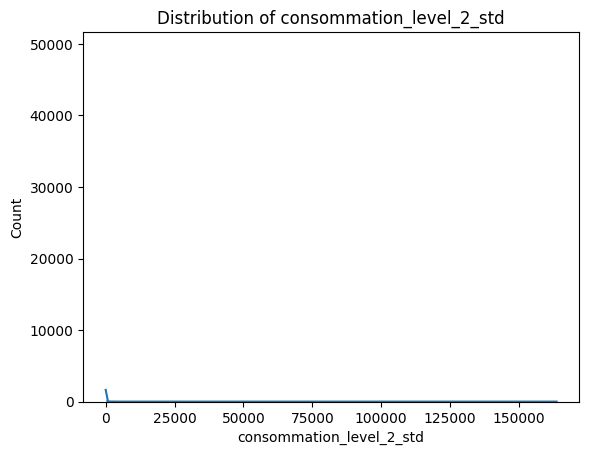

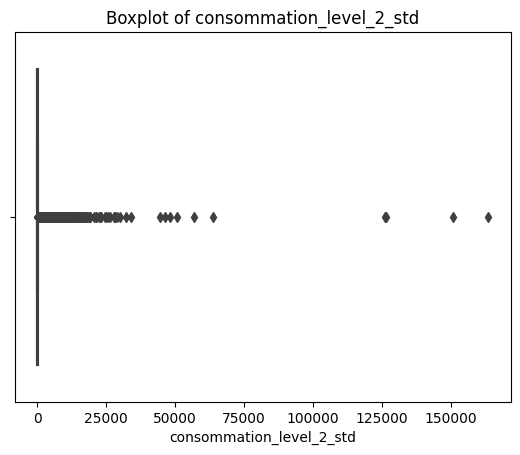

-----------------------------
consommation_level_3_mean
count    108394.000000
mean         27.696249
std         164.593535
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max       38526.857143
Name: consommation_level_3_mean, dtype: float64


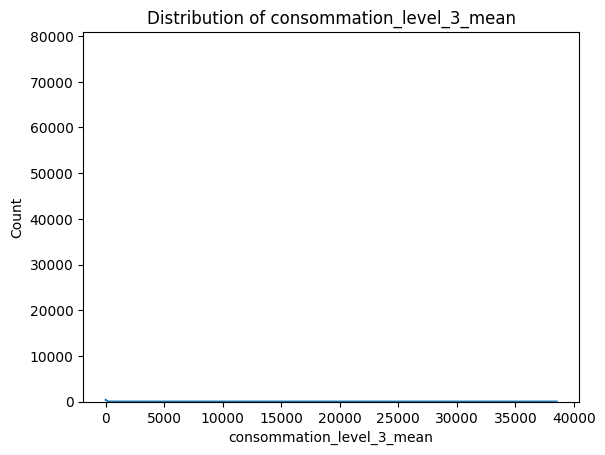

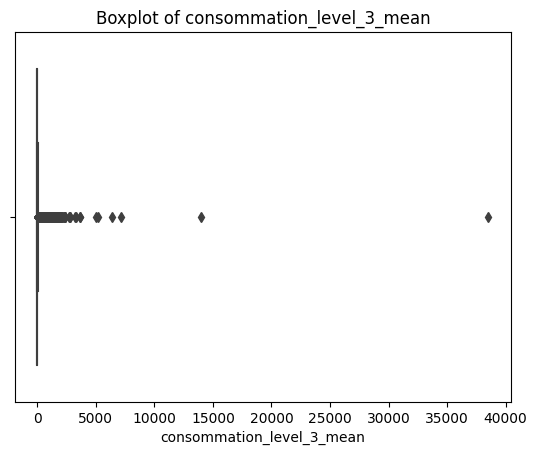

-----------------------------
consommation_level_3_std
count    108394.000000
mean         49.951737
std         137.339164
min           0.000000
25%           0.000000
50%           0.000000
75%          22.796403
max       10566.688815
Name: consommation_level_3_std, dtype: float64


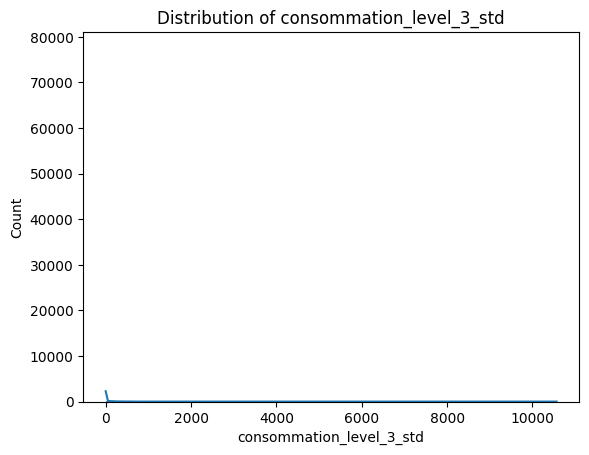

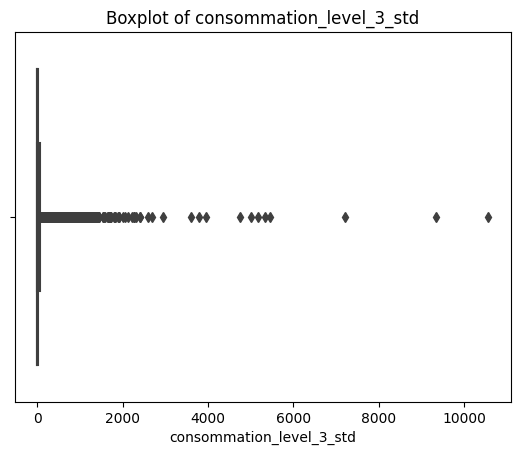

-----------------------------
consommation_level_4_mean
count    108394.000000
mean         72.861378
std         839.385642
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       79179.777778
Name: consommation_level_4_mean, dtype: float64


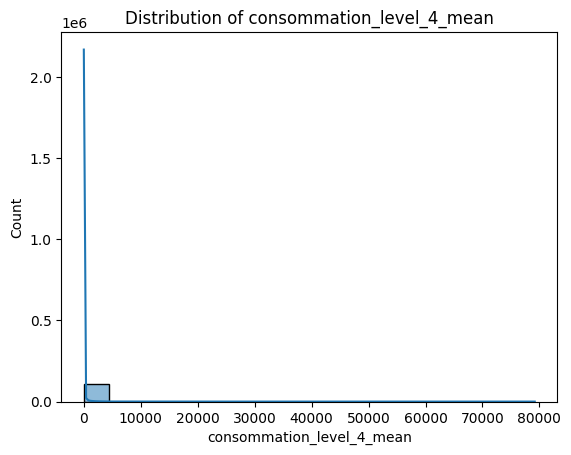

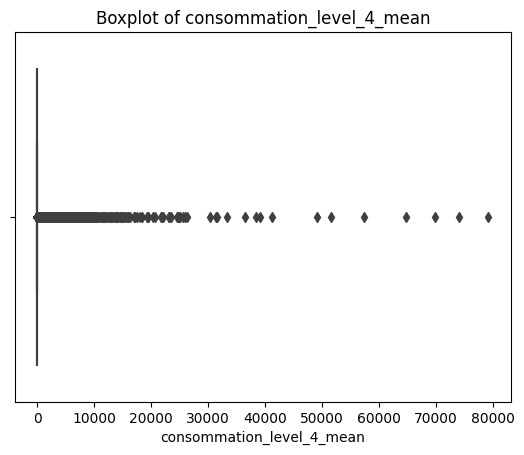

-----------------------------
consommation_level_4_std
count    108394.000000
mean        110.180642
std         937.694558
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      109586.099833
Name: consommation_level_4_std, dtype: float64


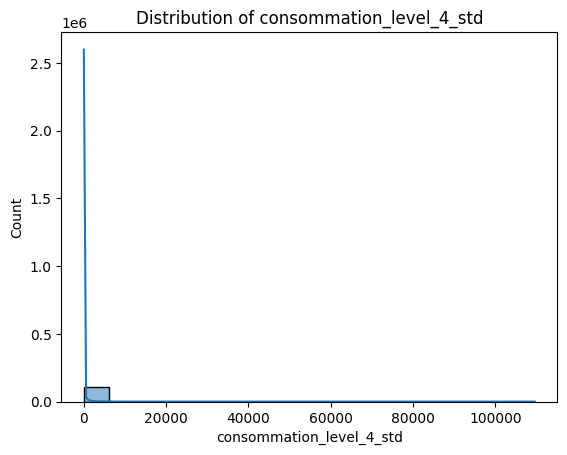

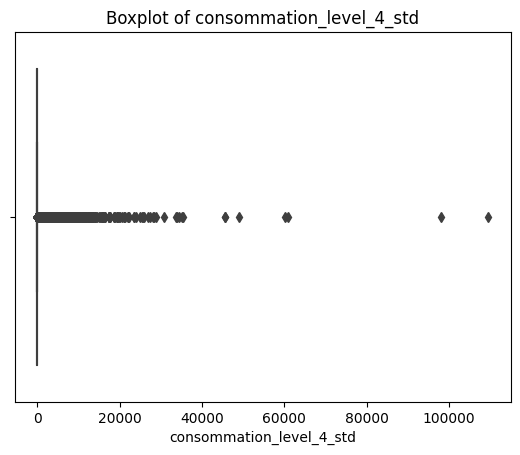

-----------------------------
diff_index_mean
count    108394.000000
mean        622.892794
std        3193.109689
min     -498591.500000
25%         227.815657
50%         388.781929
75%         634.676667
max      470540.000000
Name: diff_index_mean, dtype: float64


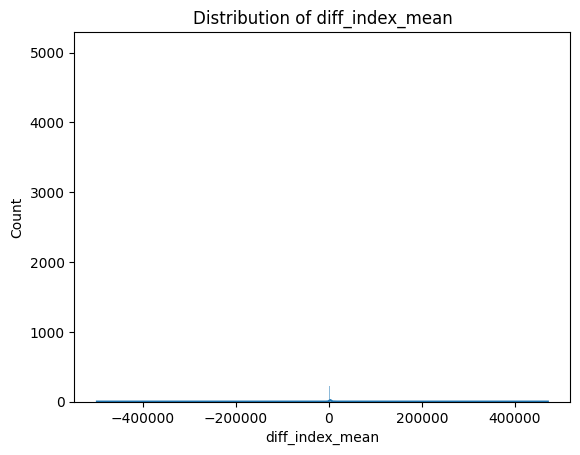

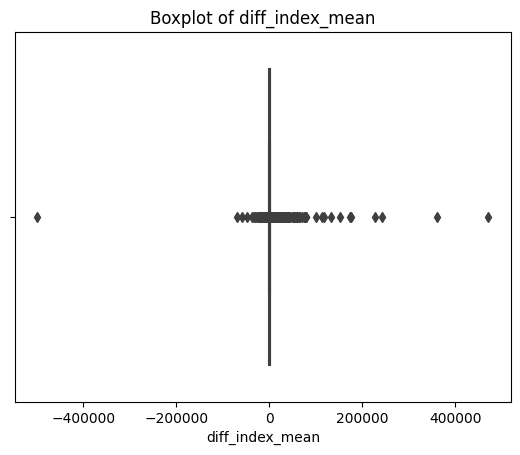

-----------------------------
diff_index_std
count    108394.000000
mean        728.980121
std        3475.303252
min           0.000000
25%         176.238055
50%         316.388869
75%         552.568852
max      707820.251929
Name: diff_index_std, dtype: float64


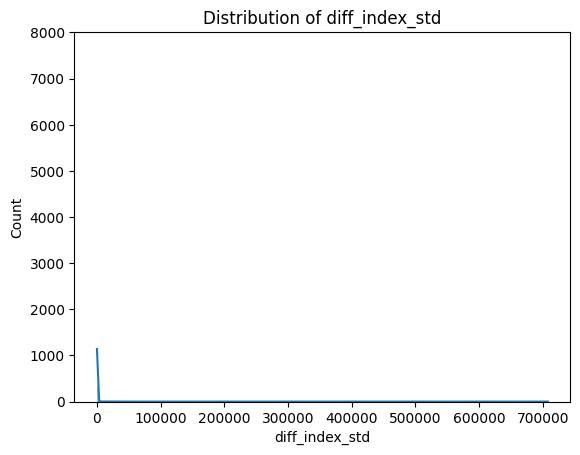

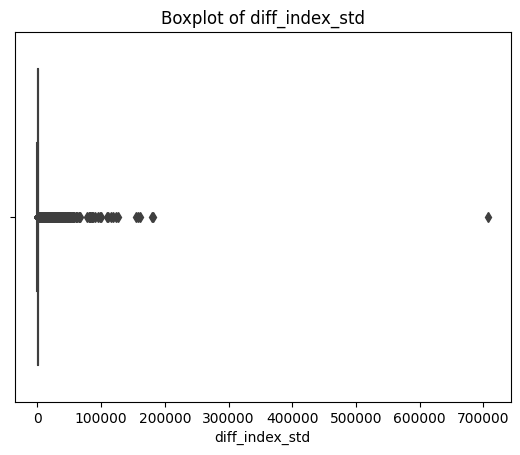

-----------------------------


In [71]:
for col in numeric_cols:    
    # Summary statistics
    print(col)
    print(X_train[col].describe())

    # Visualizations
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

    print('-----------------------------')

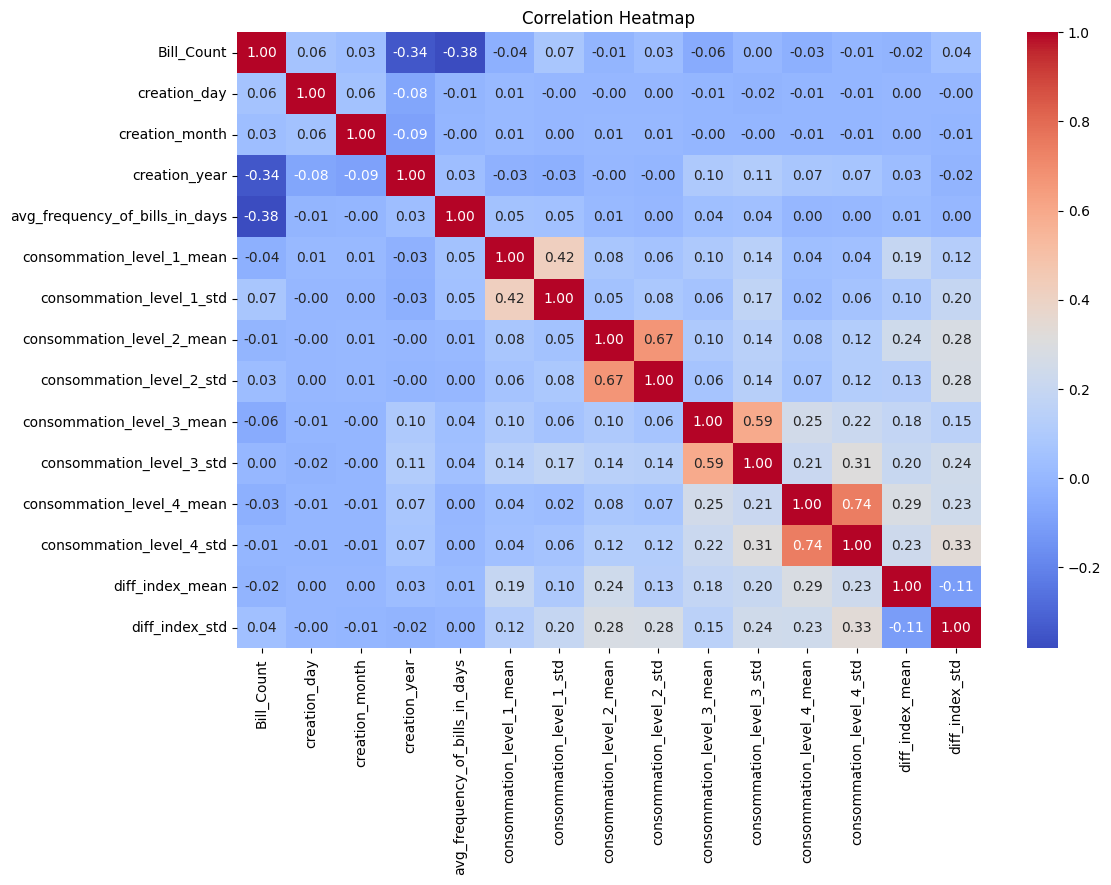

In [72]:
corr_matrix = X_train[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

#### categorical variables

We are going to do OneHotEncoding for all of our categorical variables

In [73]:
categorical_cols

['disrict',
 'client_catg',
 'region',
 'tarif_type_mode',
 'counter_coefficient_mode',
 'counter_type_mode',
 'reading_remarque_min',
 'reading_remarque_mode',
 'single_bill_client']

In [74]:
cat_cols_fe_all = ['disrict',
 'client_catg',
 'region',
 'tarif_type_mode',
 'counter_coefficient_mode',
 'counter_type_mode',
 'reading_remarque_min',
 'reading_remarque_mode']

In [75]:
ohe = OneHotEncoder(handle_unknown='ignore',drop='first', sparse=False)

In [76]:
X_train_encoded = ohe.fit_transform(X_train[cat_cols_fe_all])
X_train_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,counter_type_mode_GAZ,reading_remarque_min_6,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_413
78888,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
135126,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22992,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
57992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103628,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22143,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66946,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81271,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [77]:
X_test_encoded = ohe.transform(X_test[cat_cols_fe_all])
X_test_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,counter_type_mode_GAZ,reading_remarque_min_6,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_413
4784,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
127875,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101414,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59315,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80602,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33287,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18616,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102613,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [78]:
X_train_fe_all = X_train.copy()
X_test_fe_all = X_test.copy()

In [79]:
X_train_fe_all.drop(columns=cat_cols_fe_all, inplace=True)

In [80]:
X_train_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
78888,28,6,1,2014,60.962963,0,284.642857,290.249601,57.142857,142.539329,48.928571,174.771370,28.678571,151.752736,419.392857,634.059253
135126,65,6,12,1993,78.281250,0,222.169231,167.034949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,222.169231,167.034949
116929,4,29,12,2016,273.666667,0,312.250000,344.147619,22.750000,45.500000,0.000000,0.000000,0.000000,0.000000,335.000000,387.424831
22992,40,26,8,1994,125.410256,0,537.725000,286.300361,14.200000,67.287062,0.000000,0.000000,0.000000,0.000000,551.925000,319.649920
57992,56,14,6,1988,88.800000,0,1194.017857,992.306120,446.857143,1026.292948,29.946429,132.617347,19.821429,148.329989,1635.642857,1580.532792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103628,82,13,3,2001,62.975309,0,391.682927,409.994998,60.829268,195.262205,0.000000,0.000000,0.000000,0.000000,452.512195,544.592412
22143,1,15,4,1986,117.612903,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
66946,43,27,7,2009,83.214286,0,422.976744,461.923952,11.302326,59.920000,0.000000,0.000000,0.000000,0.000000,434.279070,492.451609
81271,46,27,10,2004,102.733333,0,420.173913,435.661913,3.978261,26.981878,0.000000,0.000000,0.000000,0.000000,424.152174,447.353600


In [81]:
# Concatenate along columns
X_train_fe_all = pd.concat([X_train_fe_all, X_train_encoded], axis=1)
X_train_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,...,counter_type_mode_GAZ,reading_remarque_min_6,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_413
78888,28,6,1,2014,60.962963,0,284.642857,290.249601,57.142857,142.539329,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
135126,65,6,12,1993,78.281250,0,222.169231,167.034949,0.000000,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116929,4,29,12,2016,273.666667,0,312.250000,344.147619,22.750000,45.500000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22992,40,26,8,1994,125.410256,0,537.725000,286.300361,14.200000,67.287062,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
57992,56,14,6,1988,88.800000,0,1194.017857,992.306120,446.857143,1026.292948,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103628,82,13,3,2001,62.975309,0,391.682927,409.994998,60.829268,195.262205,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22143,1,15,4,1986,117.612903,1,0.000000,0.000000,0.000000,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66946,43,27,7,2009,83.214286,0,422.976744,461.923952,11.302326,59.920000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81271,46,27,10,2004,102.733333,0,420.173913,435.661913,3.978261,26.981878,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [82]:
X_test_fe_all.drop(columns=cat_cols_fe_all, inplace=True)
X_test_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
4784,1,14,5,2019,117.612903,1,600.000000,0.000000,300.000000,0.000000,62.000000,0.000000,0.000000,0.000000,962.000000,0.000000
127875,74,11,7,2001,66.369863,0,433.621622,342.598359,3.891892,20.578329,0.000000,0.000000,0.000000,0.000000,437.513514,347.401755
101414,2,1,6,2006,119.000000,0,6.500000,9.192388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.500000,9.192388
59315,80,31,8,2001,63.506329,0,580.612500,376.302447,82.500000,254.609555,29.300000,113.487121,0.000000,0.000000,692.412500,555.149032
80602,8,19,1,2001,173.142857,0,558.375000,208.382846,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,558.375000,208.382846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33287,51,8,9,2009,70.440000,0,217.470588,216.945371,7.843137,56.011203,15.686275,112.022407,0.784314,5.601120,241.784314,325.741880
18616,13,13,9,1996,291.333333,0,1559.384615,2266.352302,180.000000,451.865024,14.923077,53.805919,0.000000,0.000000,1754.307692,2469.378410
102613,30,21,10,1998,53.758621,0,631.566667,525.339935,376.033333,625.417405,0.000000,0.000000,0.000000,0.000000,1007.600000,1049.547246
52082,55,10,9,2009,65.333333,0,294.890909,391.180108,81.927273,287.489314,14.545455,107.871978,35.000000,259.566947,426.200000,772.859970


In [83]:
X_test_fe_all = pd.concat([X_test_fe_all, X_test_encoded], axis=1)
X_test_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,...,counter_type_mode_GAZ,reading_remarque_min_6,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_413
4784,1,14,5,2019,117.612903,1,600.000000,0.000000,300.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
127875,74,11,7,2001,66.369863,0,433.621622,342.598359,3.891892,20.578329,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101414,2,1,6,2006,119.000000,0,6.500000,9.192388,0.000000,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59315,80,31,8,2001,63.506329,0,580.612500,376.302447,82.500000,254.609555,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80602,8,19,1,2001,173.142857,0,558.375000,208.382846,0.000000,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33287,51,8,9,2009,70.440000,0,217.470588,216.945371,7.843137,56.011203,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18616,13,13,9,1996,291.333333,0,1559.384615,2266.352302,180.000000,451.865024,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102613,30,21,10,1998,53.758621,0,631.566667,525.339935,376.033333,625.417405,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52082,55,10,9,2009,65.333333,0,294.890909,391.180108,81.927273,287.489314,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Baseline Model

In [212]:
# Create a baseline classifier with a simple strategy
baseline_clf = DummyClassifier(strategy='uniform', random_state=RSEED)

# Fit the model to the training data
baseline_clf.fit(X_train_fe_all, y_train)

# Make predictions
y_pred_bl = baseline_clf.predict(X_test_fe_all)

# Evaluate the baseline model
accuracy_bl = accuracy_score(y_test, y_pred_bl)
roc_auc_bl = roc_auc_score(y_test, y_pred_bl)
recall_bl = recall_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)
print("Baseline Accuracy:", accuracy_bl)
print("Baseline ROC AUC:", roc_auc_bl)
print("Baseline Recall:", recall_bl)
print("Baseline F1-Score:", f1_bl)
print("\nClassification Report:\n", classification_report(y_test, y_pred_bl))


Baseline Accuracy: 0.49787815048525774
Baseline ROC AUC: 0.5058722035333165
Baseline Recall: 0.5148711169861203
Baseline F1-Score: 0.10273656445763271

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.50      0.65     25586
         1.0       0.06      0.51      0.10      1513

    accuracy                           0.50     27099
   macro avg       0.50      0.51      0.38     27099
weighted avg       0.90      0.50      0.62     27099



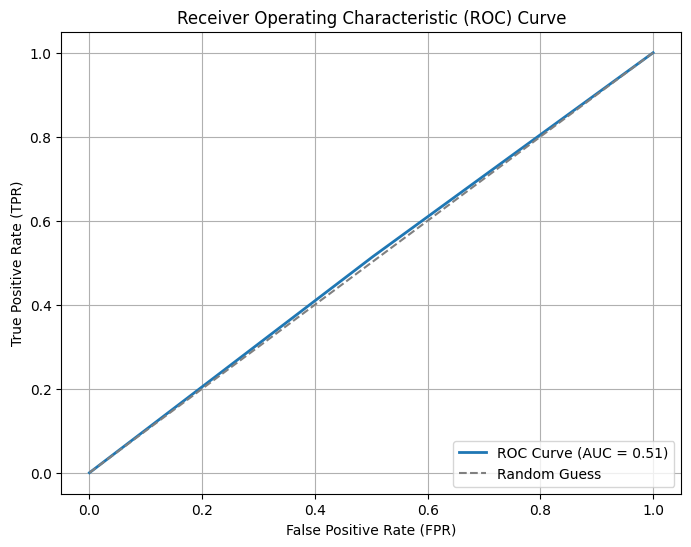

In [213]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_bl)

# Compute the AUC score
roc_auc = roc_auc_score(y_test, y_pred_bl)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")  # Diagonal line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [214]:
cm = confusion_matrix(y_test, y_pred_bl)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[12713 12873]
 [  734   779]]


### Handleing Data Imbalance

We can see from our baseline we have 94 % accuracy but all other metrics are poor. Since the metric we are using is AUC we can see that it is 0.5 which is just as good as random guessing. Before we proceed and train and test other models, we have to take care of this data imbalance. we can do this by SMOTE.

### SMOTE

In [85]:
# Instantiating smote
smote = SMOTE()
# Fitting smote
X_train_fe_all_smote, y_train_smote= smote.fit_resample(X_train_fe_all, y_train)

In [86]:
y_train_smote.value_counts(normalize=True)

target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

As we can see, we made it go from a imbalanced data class to a balanced data class


### Modeling

#### Logistic Regression

In [87]:
logreg = LogisticRegression(
    max_iter=1000,      # Increase iterations if you have many features
    class_weight='balanced',  # Optional if data is imbalanced
    random_state=RSEED
)

In [88]:
scaler = StandardScaler()

In [89]:
X_train_scale = scaler.fit_transform(X_train_fe_all_smote)

In [90]:
X_test_scale = scaler.transform(X_test_fe_all)

In [91]:
logreg.fit(X_train_scale, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=101)

In [92]:
y_pred_lr = logreg.predict(X_test_scale)

In [93]:
# Get probabilities for the positive class
y_proba_lr = logreg.predict_proba(X_test_scale)[:, 1]


In [94]:
# Evaluate the baseline model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

LR Accuracy: 0.6717591055020481
LR ROC AUC: 0.6604502038638633
LR Recall: 0.6477197620621282
LR F1-Score: 0.18056195301704284

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.65      0.18      1513

    accuracy                           0.67     27099
   macro avg       0.54      0.66      0.49     27099
weighted avg       0.92      0.67      0.76     27099



In [180]:
threshold = 0.5  # You can experiment with different values
y_pred_adjusted = (y_proba_lr >= threshold).astype(int)

In [181]:
# Evaluate the baseline model
accuracy_lr = accuracy_score(y_test, y_pred_adjusted)
roc_auc_lr = roc_auc_score(y_test, y_pred_adjusted)
recall_lr = recall_score(y_test, y_pred_adjusted)
f1_lr = f1_score(y_test, y_pred_adjusted)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted))

LR Accuracy: 0.6717591055020481
LR ROC AUC: 0.6604502038638633
LR Recall: 0.6477197620621282
LR F1-Score: 0.18056195301704284

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.65      0.18      1513

    accuracy                           0.67     27099
   macro avg       0.54      0.66      0.49     27099
weighted avg       0.92      0.67      0.76     27099



In [125]:
cm = confusion_matrix(y_test, y_pred_adjusted)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[17224  8362]
 [  533   980]]


#### Decision Tree

In [138]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, classification_report

# Initialize Decision Tree model
dt = DecisionTreeClassifier(
    criterion='gini',      # Splitting criterion ('gini' or 'entropy')
    max_depth=8,        # Maximum depth of the tree (None for no limit)
    min_samples_split=2,   # Minimum number of samples required to split an internal node
    min_samples_leaf=1,    # Minimum number of samples required to be at a leaf node
    random_state=RSEED        # Random state for reproducibility
)

# Train the Decision Tree model
dt.fit(X_train_fe_all_smote, y_train_smote)

# Predict on the test set
y_pred_dt = dt.predict(X_test_fe_all)

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree ROC AUC:", roc_auc_dt)
print("Decision Tree Recall:", recall_dt)
print("Decision Tree F1-Score:", f1_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


Decision Tree Accuracy: 0.8805121960219934
Decision Tree ROC AUC: 0.587862744460849
Decision Tree Recall: 0.25842696629213485
Decision Tree F1-Score: 0.19452736318407962

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.92      0.94     25586
         1.0       0.16      0.26      0.19      1513

    accuracy                           0.88     27099
   macro avg       0.56      0.59      0.56     27099
weighted avg       0.91      0.88      0.89     27099

Confusion Matrix:
[[23470  2116]
 [ 1122   391]]


#### Random Forest 

In [147]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, classification_report

# Initialize Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,          # Number of trees in the forest
    criterion='gini',          # Splitting criterion ('gini' or 'entropy')
    max_depth=7,            # Maximum depth of the tree (None for no limit)
    min_samples_split=2,       # Minimum number of samples required to split an internal node
    min_samples_leaf=1,        # Minimum number of samples required to be at a leaf node
    random_state=RSEED,           # Random state for reproducibility
    class_weight='balanced'    # Handle class imbalance
)

# Train the Random Forest model
rf.fit(X_train_fe_all_smote, y_train_smote)

# Predict on the test set
y_pred_rf = rf.predict(X_test_fe_all)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest ROC AUC:", roc_auc_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest F1-Score:", f1_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


Random Forest Accuracy: 0.8236466290269013
Random Forest ROC AUC: 0.6065642102585328
Random Forest Recall: 0.3621943159286186
Random Forest F1-Score: 0.1865531914893617

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.85      0.90     25586
         1.0       0.13      0.36      0.19      1513

    accuracy                           0.82     27099
   macro avg       0.54      0.61      0.54     27099
weighted avg       0.91      0.82      0.86     27099

Confusion Matrix:
[[21772  3814]
 [  965   548]]


#### XGBoost

In [150]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, classification_report

# Initialize XGBoost model
xgb = XGBClassifier(
    n_estimators=100,          # Number of boosting rounds
    learning_rate=0.1,         # Step size shrinkage
    max_depth=6,               # Maximum depth of a tree
    subsample=0.8,             # Subsample ratio of the training instances
    colsample_bytree=0.8,      # Subsample ratio of columns when constructing each tree
    scale_pos_weight=1,        # Control the balance of positive and negative weights
    use_label_encoder=False,   # Disable label encoding for binary classification
    eval_metric='logloss',     # Evaluation metric
    random_state=RSEED            # Random state for reproducibility
)

# Train the XGBoost model
xgb.fit(X_train_fe_all_smote, y_train_smote)

# Predict on the test set
y_pred_xgb = xgb.predict(X_test_fe_all)

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost ROC AUC:", roc_auc_xgb)
print("XGBoost Recall:", recall_xgb)
print("XGBoost F1-Score:", f1_xgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


XGBoost Accuracy: 0.9395918668585557
XGBoost ROC AUC: 0.5249384047962036
XGBoost Recall: 0.05816259087904825
XGBoost F1-Score: 0.09707666850523994

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     25586
         1.0       0.29      0.06      0.10      1513

    accuracy                           0.94     27099
   macro avg       0.62      0.52      0.53     27099
weighted avg       0.91      0.94      0.92     27099

Confusion Matrix:
[[25374   212]
 [ 1425    88]]


### RandomSearchCV

#### For Logistic Regression

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END C=1.8152165622510308, class_weight=balanced, max_iter=500, penalty=l2, solver=liblinear, tol=0.00029934229394023285; total time=   5.4s


/Users/rahulgeorge/Desktop/Coriander_heatmap/pair_exercise/ML-Project-Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/rahulgeorge/Desktop/Coriander_heatmap/pair_exercise/ML-Project-Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

[CV] END C=5.263986277024461, class_weight=balanced, max_iter=500, penalty=l2, solver=lbfgs, tol=3.847422647809694e-05; total time=   9.8s
[CV] END C=5.263986277024461, class_weight=balanced, max_iter=500, penalty=l2, solver=lbfgs, tol=3.847422647809694e-05; total time=  10.0s
[CV] END C=5.263986277024461, class_weight=balanced, max_iter=500, penalty=l2, solver=lbfgs, tol=3.847422647809694e-05; total time=  10.1s


/Users/rahulgeorge/Desktop/Coriander_heatmap/pair_exercise/ML-Project-Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END C=5.263986277024461, class_weight=balanced, max_iter=500, penalty=l2, solver=lbfgs, tol=3.847422647809694e-05; total time=  10.4s


...

[CV] END C=2.132051253779174, class_weight=balanced, max_iter=100, penalty=l2, solver=liblinear, tol=5.55096611583109e-05; total time=  14.9s


/Users/rahulgeorge/Desktop/Coriander_heatmap/pair_exercise/ML-Project-Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END C=2.132051253779174, class_weight=balanced, max_iter=100, penalty=l2, solver=liblinear, tol=5.55096611583109e-05; total time=  16.2s


/Users/rahulgeorge/Desktop/Coriander_heatmap/pair_exercise/ML-Project-Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END C=2.132051253779174, class_weight=balanced, max_iter=100, penalty=l2, solver=liblinear, tol=5.55096611583109e-05; total time=  18.7s
[CV] END C=8.950411885456099, class_weight=balanced, max_iter=1000, penalty=l2, solver=liblinear, tol=0.0005909244012043348; total time=   9.3s
[CV] END C=8.950411885456099, class_weight=balanced, max_iter=1000, penalty=l2, solver=liblinear, tol=0.0005909244012043348; total time=  12.5s
[CV] END C=2.1326229240562533, class_weight=balanced, max_iter=500, penalty=l2, solver=liblinear, tol=0.0005951955645577825; total time= 1.1min
[CV] END C=9.206622626825345, class_weight=balanced, max_iter=1000, penalty=l2, solver=liblinear, tol=7.222403964193912e-05; total time=  11.7s
[CV] END C=9.206622626825345, class_weight=balanced, max_iter=1000, penalty=l2, solver=liblinear, tol=7.222403964193912e-05; total time=  14.9s
[CV] END C=8.950411885456099, class_weight=balanced, max_iter=1000, penalty=l2, solver=liblinear, tol=0.0005909244012043348; total time=  

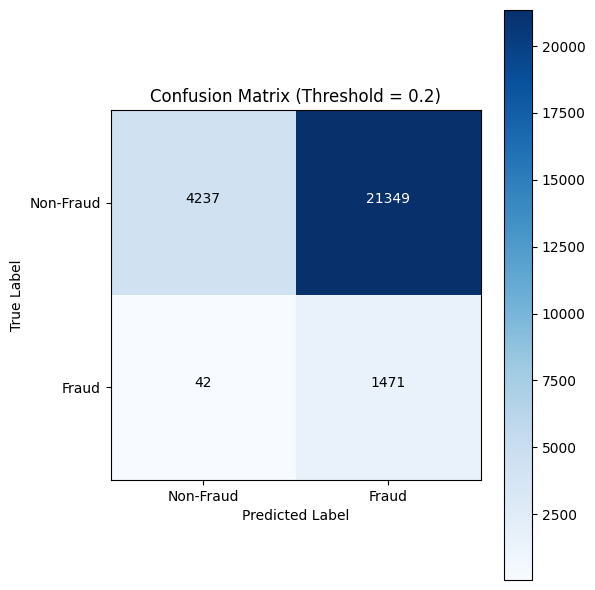


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.99      0.33      0.50     25586
         1.0       0.08      0.92      0.14      1513

    accuracy                           0.37     27099
   macro avg       0.53      0.63      0.32     27099
weighted avg       0.94      0.37      0.48     27099



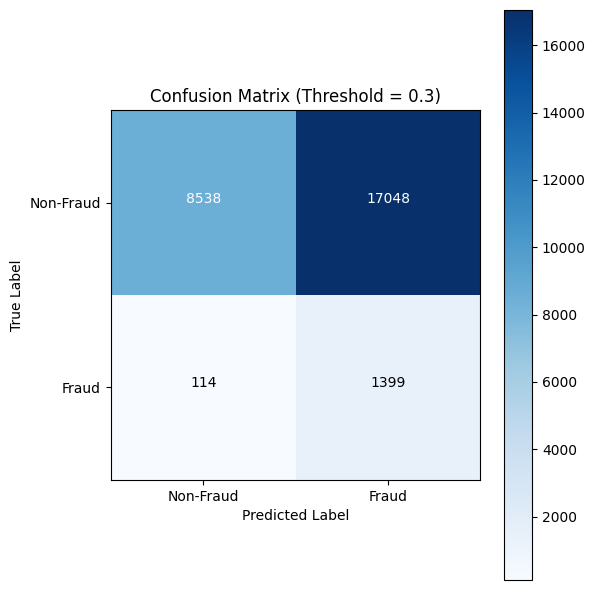


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.98      0.50      0.66     25586
         1.0       0.09      0.81      0.16      1513

    accuracy                           0.52     27099
   macro avg       0.53      0.65      0.41     27099
weighted avg       0.93      0.52      0.64     27099



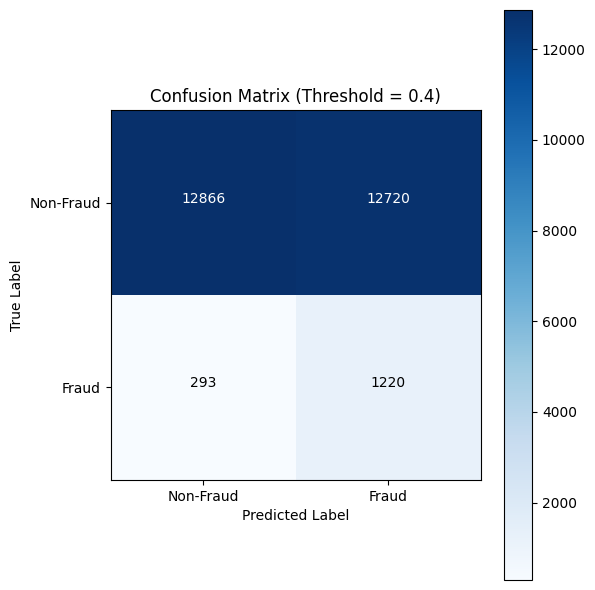


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



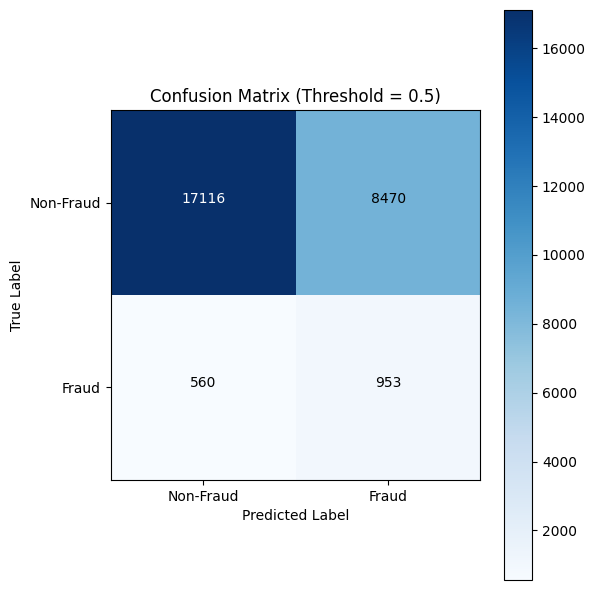

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
from scipy.stats import uniform
import matplotlib.pyplot as plt
import numpy as np

# Apply SMOTETomek to handle class imbalance
smote_tomek = SMOTETomek(random_state=RSEED)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_fe_all, y_train)

# Define the parameter distribution
param_dist = {
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'C': uniform(0.1, 10),             # Regularization strength
    'tol': uniform(1e-5, 1e-3),        # Convergence tolerance
    'max_iter': [100, 500, 1000],      # Maximum iterations
    'class_weight': ['balanced']       # Handle class imbalance
}

# Initialize Logistic Regression
log_reg = LogisticRegression(random_state=RSEED)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,                        # Number of iterations
    scoring='recall',                 # Optimize for recall
    cv=5,                             # 5-fold cross-validation
    verbose=2,                        # Show progress
    n_jobs=-1,                        # Use all processors
    random_state=RSEED                   # Reproducibility
)

# Fit the RandomizedSearchCV
random_search.fit(X_resampled, y_resampled)

# Print the best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Recall Score:", random_search.best_score_)

# Use the best estimator for evaluation
best_log_reg = random_search.best_estimator_

# Make predictions
y_pred = best_log_reg.predict(X_test_fe_all)

# Predict probabilities for the positive class
y_proba = best_log_reg.predict_proba(X_test_fe_all)[:, 1]



# Threshold adjustment and confusion matrix plotting
thresholds = [0.2, 0.3, 0.4, 0.5]
for threshold in thresholds:
    print(f"\nThreshold: {threshold}")
    y_pred_adjusted_lr = (y_proba >= threshold).astype(int)
    print(classification_report(y_test, y_pred_adjusted_lr))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_adjusted_lr)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.colorbar()
    plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.yticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Annotate confusion matrix
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f'{cm[i, j]}', horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()


In [102]:
accuracy_lr = accuracy_score(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

LR Accuracy: 0.6667773718587402
LR ROC AUC: 0.6494170044765373
LR Recall: 0.6298744216787838
LR F1-Score: 0.17428675932699342

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [220]:
threshold = 0.4  # You can experiment with different values
y_pred_adjusted_lr = (y_proba >= threshold).astype(int)

In [221]:
# Evaluate the baseline model
accuracy_lr = accuracy_score(y_test, y_pred_adjusted_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_adjusted_lr)
recall_lr = recall_score(y_test, y_pred_adjusted_lr)
f1_lr = f1_score(y_test, y_pred_adjusted_lr)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted_lr))

cm = confusion_matrix(y_test, y_pred_adjusted_lr)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

LR Accuracy: 0.5197977785158124
LR ROC AUC: 0.654599066357805
LR Recall: 0.806345009914078
LR F1-Score: 0.15789814275545203

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.50      0.66     25586
         1.0       0.09      0.81      0.16      1513

    accuracy                           0.52     27099
   macro avg       0.53      0.65      0.41     27099
weighted avg       0.93      0.52      0.64     27099

Confusion Matrix:
[[12866 12720]
 [  293  1220]]


#### For Decision Tree

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END class_weight=balanced, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=7, min_samples_split=13, splitter=best; total time=   0.9s
[CV] END class_weight=balanced, criterion=entropy, max_depth=20, max_features=log2, min_samples_leaf=9, min_samples_split=6, splitter=best; total time=   1.0s
[CV] END class_weight=balanced, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=7, min_samples_split=13, splitter=best; total time=   1.1s
[CV] END class_weight=balanced, criterion=entropy, max_depth=20, max_features=log2, min_samples_leaf=9, min_samples_split=6, splitter=best; total time=   1.2s
[CV] END class_weight=balanced, criterion=entropy, max_depth=20, max_features=log2, min_samples_leaf=9, min_samples_split=6, splitter=best; total time=   1.2s
[CV] END class_weight=balanced, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=7, min_samples_split=13, splitter=

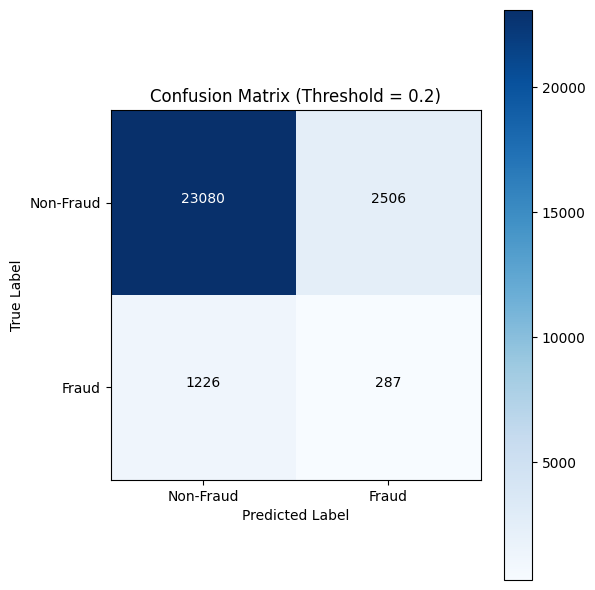


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93     25586
         1.0       0.11      0.18      0.14      1513

    accuracy                           0.87     27099
   macro avg       0.53      0.55      0.53     27099
weighted avg       0.90      0.87      0.88     27099



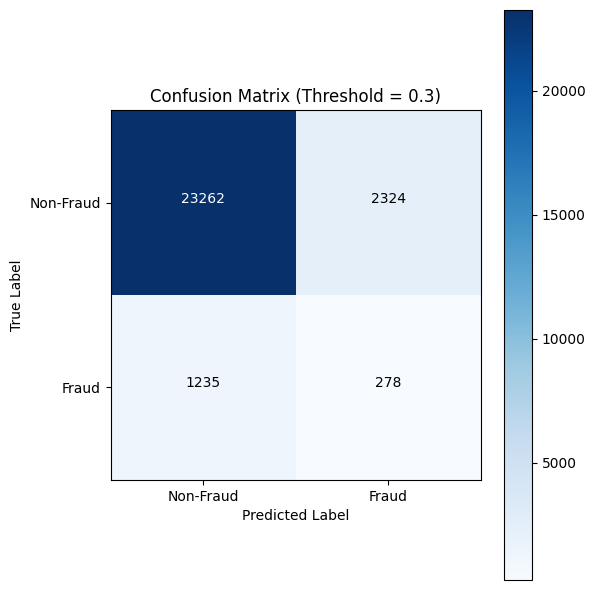


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93     25586
         1.0       0.11      0.17      0.13      1513

    accuracy                           0.87     27099
   macro avg       0.53      0.55      0.53     27099
weighted avg       0.90      0.87      0.89     27099



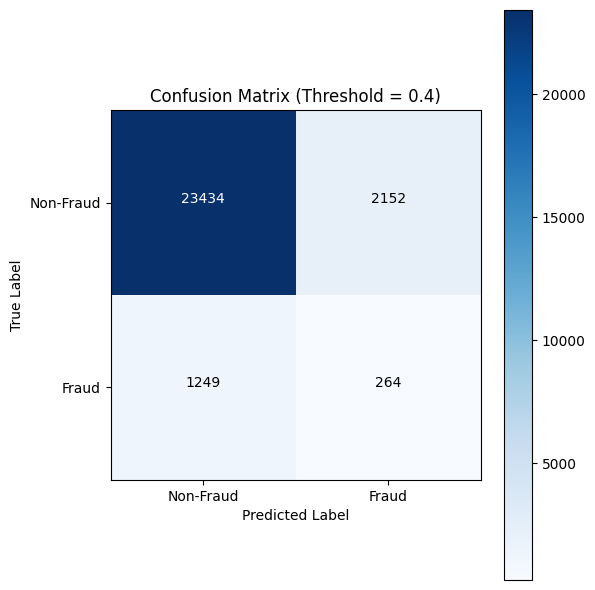


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93     25586
         1.0       0.11      0.17      0.13      1513

    accuracy                           0.87     27099
   macro avg       0.53      0.55      0.53     27099
weighted avg       0.90      0.87      0.89     27099



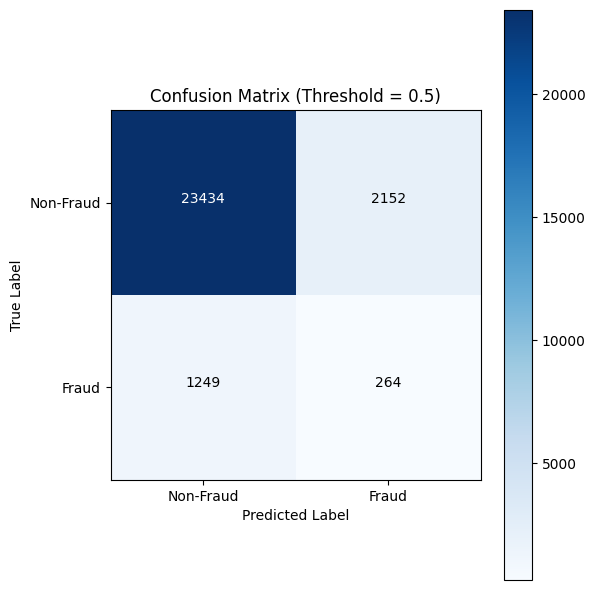

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import numpy as np

# Apply SMOTETomek to handle class imbalance
smote_tomek = SMOTETomek(random_state=RSEED)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_fe_all, y_train)

# Define the parameter distribution
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best'],                # Avoid 'random' for deterministic splits
    'max_depth': [10, 20, 30],     # Restrict depth to prevent overfitting
    'min_samples_split': randint(2, 20), # Minimum samples required to split
    'min_samples_leaf': randint(1, 10),  # Minimum samples per leaf
    'class_weight': ['balanced'],        # Address class imbalance
    'max_features': ['sqrt', 'log2', None]
}

# Initialize Decision Tree model
dt = DecisionTreeClassifier(random_state=RSEED)

# Initialize RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    n_iter=50,               # Number of parameter combinations to sample
    scoring='recall',        # Optimize for recall
    cv=5,                    # 5-fold cross-validation
    verbose=2,               # Display progress
    n_jobs=-1,               # Use all processors
    random_state=RSEED          # Ensure reproducibility
)

# Fit RandomizedSearchCV
random_search_dt.fit(X_resampled, y_resampled)

# Print the best parameters and score
print("Best Parameters for Decision Tree:", random_search_dt.best_params_)
print("Best Recall Score for Decision Tree:", random_search_dt.best_score_)

# Use the best estimator for evaluation
best_dt = random_search_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test_fe_all)

# Predict probabilities for threshold adjustment
y_proba_dt = best_dt.predict_proba(X_test_fe_all)[:, 1]

# Threshold adjustment and confusion matrix plotting
thresholds = [0.2, 0.3, 0.4, 0.5]
for threshold in thresholds:
    print(f"\nThreshold: {threshold}")
    y_pred_adjusted_dt = (y_proba_dt >= threshold).astype(int)
    print(classification_report(y_test, y_pred_adjusted_dt))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_adjusted_dt)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.colorbar()
    plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.yticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Annotate confusion matrix
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f'{cm[i, j]}', horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()


In [105]:
# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree ROC AUC:", roc_auc_dt)
print("Decision Tree Recall:", recall_dt)
print("Decision Tree F1-Score:", f1_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Decision Tree Accuracy: 0.9026532344366951
Decision Tree ROC AUC: 0.5339822401636635
Decision Tree Recall: 0.11896893588896233
Decision Tree F1-Score: 0.1200800533689126

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.95      0.95     25586
         1.0       0.12      0.12      0.12      1513

    accuracy                           0.90     27099
   macro avg       0.53      0.53      0.53     27099
weighted avg       0.90      0.90      0.90     27099

Confusion Matrix:
[[24281  1305]
 [ 1333   180]]


#### For Random Forest

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, class_weight=balanced, criterion=entropy, max_depth=19, max_features=log2, min_samples_leaf=13, min_samples_split=14, n_estimators=163; total time=  51.8s
[CV] END bootstrap=True, class_weight=balanced, criterion=entropy, max_depth=19, max_features=log2, min_samples_leaf=13, min_samples_split=14, n_estimators=163; total time=  53.3s
[CV] END bootstrap=True, class_weight=balanced, criterion=entropy, max_depth=19, max_features=log2, min_samples_leaf=13, min_samples_split=14, n_estimators=163; total time=  54.2s
[CV] END bootstrap=True, class_weight=balanced, criterion=entropy, max_depth=21, max_features=log2, min_samples_leaf=11, min_samples_split=33, n_estimators=175; total time=  58.3s
[CV] END bootstrap=True, class_weight=balanced, criterion=entropy, max_depth=21, max_features=log2, min_samples_leaf=11, min_samples_split=33, n_estimators=175; total time=  58.4s
[CV] END bootstrap=True, class_weight=

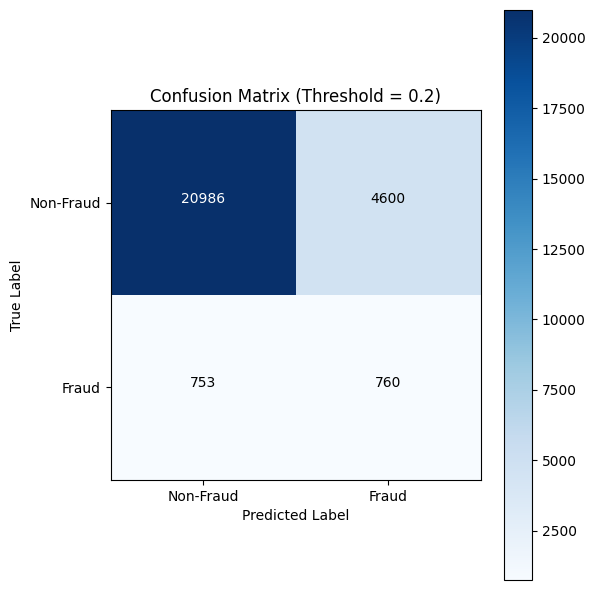


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94     25586
         1.0       0.19      0.27      0.22      1513

    accuracy                           0.89     27099
   macro avg       0.57      0.60      0.58     27099
weighted avg       0.91      0.89      0.90     27099



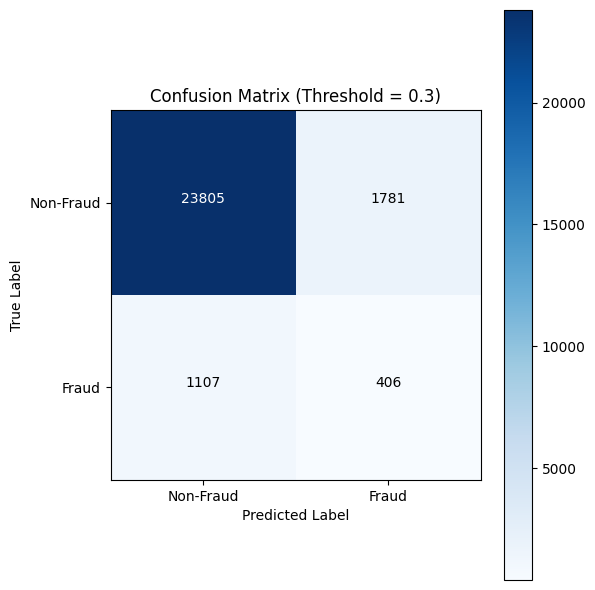


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     25586
         1.0       0.24      0.14      0.18      1513

    accuracy                           0.93     27099
   macro avg       0.60      0.56      0.57     27099
weighted avg       0.91      0.93      0.92     27099



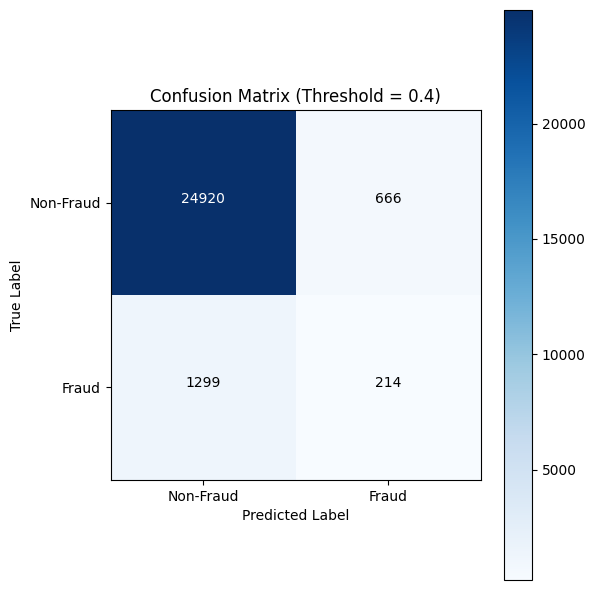


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     25586
         1.0       0.30      0.06      0.11      1513

    accuracy                           0.94     27099
   macro avg       0.62      0.53      0.54     27099
weighted avg       0.91      0.94      0.92     27099



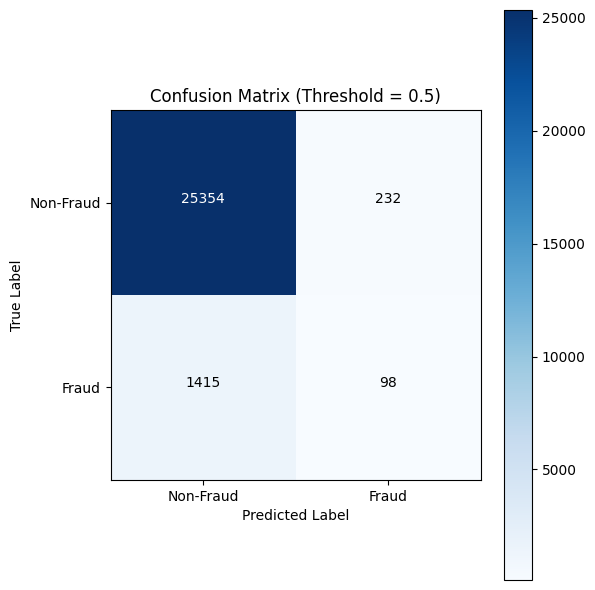

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import numpy as np

# Apply SMOTETomek to handle class imbalance
smote_tomek = SMOTETomek(random_state=RSEED)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_fe_all, y_train)

# Define the parameter distribution
param_dist_rf = {
    'n_estimators': randint(100, 200),              # Focused range for number of trees
    'max_depth': randint(10, 30),                  # Shallower trees to prevent overfitting
    'min_samples_split': randint(10, 50),          # Ensure splits are on sufficient data
    'min_samples_leaf': randint(5, 20),            # Prevent overly fine splits
    'max_features': ['sqrt', 'log2'],              # Limit features for splits
    'bootstrap': [True],                           # Use bootstrapping for diversity
    'criterion': ['gini', 'entropy'],              # Test both criteria
    'class_weight': ['balanced'],                  # Penalize majority class misclassification
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=RSEED)

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=50,               # Number of parameter combinations to sample
    scoring='recall',        # Optimize for recall
    cv=5,                    # 5-fold cross-validation
    verbose=2,               # Display progress
    n_jobs=-1,               # Use all processors
    random_state=RSEED          # Ensure reproducibility
)

# Fit RandomizedSearchCV
random_search_rf.fit(X_resampled, y_resampled)

# Print the best parameters and score
print("Best Parameters for Random Forest:", random_search_rf.best_params_)
print("Best Recall Score for Random Forest:", random_search_rf.best_score_)

# Use the best estimator for evaluation
best_rf = random_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_fe_all)

# Predict probabilities for threshold adjustment
y_proba_rf = best_rf.predict_proba(X_test_fe_all)[:, 1]

# Threshold adjustment and confusion matrix plotting
thresholds = [0.2, 0.3, 0.4, 0.5]
for threshold in thresholds:
    print(f"\nThreshold: {threshold}")
    y_pred_adjusted_rf = (y_proba_rf >= threshold).astype(int)
    print(classification_report(y_test, y_pred_adjusted_rf))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_adjusted_rf)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.colorbar()
    plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.yticks([0, 1], ['Non-Fraud', 'Fraud'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Annotate confusion matrix
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f'{cm[i, j]}', horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()


In [107]:
# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest ROC AUC:", roc_auc_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest F1-Score:", f1_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Random Forest Accuracy: 0.9392228495516439
Random Forest ROC AUC: 0.52785225871985
Random Forest Recall: 0.06477197620621282
Random Forest F1-Score: 0.10634834508952794

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     25586
         1.0       0.30      0.06      0.11      1513

    accuracy                           0.94     27099
   macro avg       0.62      0.53      0.54     27099
weighted avg       0.91      0.94      0.92     27099

Confusion Matrix:
[[25354   232]
 [ 1415    98]]


#### For XGBoost

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8032797255404892, gamma=0.17120027606044194, learning_rate=0.012847422647809695, max_depth=6, min_child_weight=3, n_estimators=177, scale_pos_weight=1.0, subsample=0.7613932439344475; total time= 2.4min
[CV] END colsample_bytree=0.8032797255404892, gamma=0.17120027606044194, learning_rate=0.012847422647809695, max_depth=6, min_child_weight=3, n_estimators=177, scale_pos_weight=1.0, subsample=0.7613932439344475; total time= 2.4min
[CV] END colsample_bytree=0.8032797255404892, gamma=0.17120027606044194, learning_rate=0.012847422647809695, max_depth=6, min_child_weight=3, n_estimators=177, scale_pos_weight=1.0, subsample=0.7613932439344475; total time= 2.4min
[CV] END colsample_bytree=0.8032797255404892, gamma=0.17120027606044194, learning_rate=0.012847422647809695, max_depth=6, min_child_weight=3, n_estimators=177, scale_pos_weight=1.0, subsample=0.7613932439344475; total time= 2.4min
[CV] END colsa

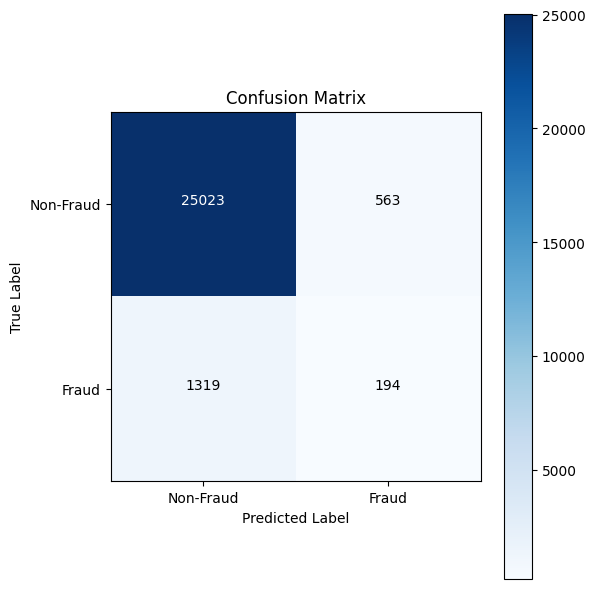


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.97      0.81      0.88     25586
         1.0       0.13      0.51      0.21      1513

    accuracy                           0.79     27099
   macro avg       0.55      0.66      0.55     27099
weighted avg       0.92      0.79      0.84     27099


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.96      0.91      0.93     25586
         1.0       0.18      0.34      0.23      1513

    accuracy                           0.87     27099
   macro avg       0.57      0.62      0.58     27099
weighted avg       0.91      0.87      0.89     27099


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95     25586
         1.0       0.21      0.21      0.21      1513

    accuracy                           0.91     27099
   macro avg       0.58      0.58      0.58     27099
weighted avg       0.91   

In [108]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import numpy as np


scale_pos_weight = len(y_train_smote[y_train_smote == 0]) / len(y_train_smote[y_train_smote == 1])

# Resample the data using SMOTETomek to reduce noise and balance classes
smote_tomek = SMOTETomek(random_state=RSEED)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_fe_all, y_train)

# Define parameter distribution
param_dist_xgb = {
    'max_depth': [5, 6, 7],                         # Limit tree depth for better generalization
    'min_child_weight': [1, 3, 5],                 # Balance splits with fewer samples
    'subsample': uniform(0.7, 0.2),                # Focus on 70%-90% of data per tree
    'colsample_bytree': uniform(0.7, 0.2),         # Use a subset of features per tree
    'learning_rate': uniform(0.01, 0.1),           # Smaller learning rate for stability
    'n_estimators': randint(100, 200),             # Reasonable range for boosting rounds
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5],  # Penalize majority class
    'gamma': uniform(0, 0.3)                       # Minimum loss reduction for splits
}

# Initialize XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RSEED)

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,               # Reduce iterations to save computation time
    scoring='recall',        # Optimize for recall
    cv=5,                    # 5-fold cross-validation
    verbose=2,               # Display progress
    n_jobs=-1,               # Use all processors
    random_state=RSEED          # Ensure reproducibility
)

# Fit the RandomizedSearchCV
random_search_xgb.fit(X_resampled, y_resampled)

# Print best parameters and recall score
print("Best Parameters for XGBoost:", random_search_xgb.best_params_)
print("Best Recall Score for XGBoost:", random_search_xgb.best_score_)

# Evaluate the best estimator on the test set
best_xgb = random_search_xgb.best_estimator_
y_proba_xgb = best_xgb.predict_proba(X_test_fe_all)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)  # Default threshold is 0.5

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)  # Use probabilities for ROC AUC
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost ROC AUC:", roc_auc_xgb)
print("XGBoost Recall:", recall_xgb)
print("XGBoost F1-Score:", f1_xgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.yticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Annotate confusion matrix
thresh = cm.max() / 2
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, f'{cm[i, j]}', horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

# Adjust thresholds to improve recall
thresholds = [0.2, 0.3, 0.4, 0.5]
for threshold in thresholds:
    print(f"\nThreshold: {threshold}")
    y_pred_adjusted_xgb = (y_proba_xgb >= threshold).astype(int)
    print(classification_report(y_test, y_pred_adjusted_xgb))


In [207]:
y_pred_adjusted_xgb = (y_proba_xgb >= 0.2).astype(int)

In [208]:
accuracy_xgb_adjusted = accuracy_score(y_test, y_pred_adjusted_xgb)
roc_auc_xgb_adjusted = roc_auc_score(y_test, y_pred_adjusted_xgb)  # Use probabilities for ROC AUC
recall_xgb_adjusted = recall_score(y_test, y_pred_adjusted_xgb)
f1_xgb_adjusted = f1_score(y_test, y_pred_adjusted_xgb)

print("XGBoost Accuracy:", accuracy_xgb_adjusted)
print("XGBoost ROC AUC:", roc_auc_xgb_adjusted)
print("XGBoost Recall:", recall_xgb_adjusted)
print("XGBoost F1-Score:", f1_xgb_adjusted)
print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted_xgb))

XGBoost Accuracy: 0.7905826783276135
XGBoost ROC AUC: 0.6574586471689198
XGBoost Recall: 0.5076007931262393
XGBoost F1-Score: 0.2130079045902094

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.81      0.88     25586
         1.0       0.13      0.51      0.21      1513

    accuracy                           0.79     27099
   macro avg       0.55      0.66      0.55     27099
weighted avg       0.92      0.79      0.84     27099



Confusion Matrix:
[[20656  4930]
 [  745   768]]


Text(0, 0.5, 'True Label')

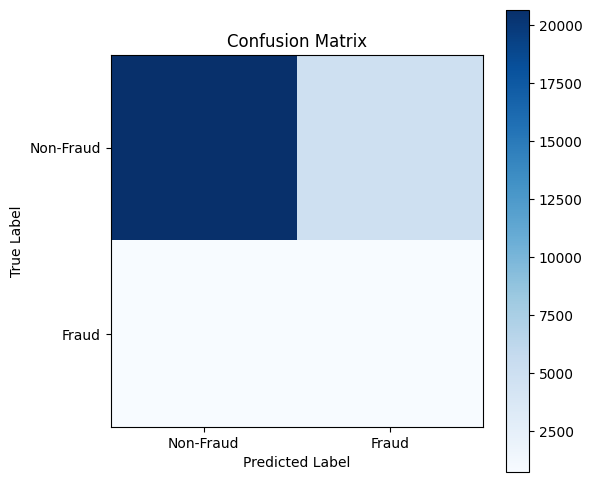

In [209]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_adjusted_xgb)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.yticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

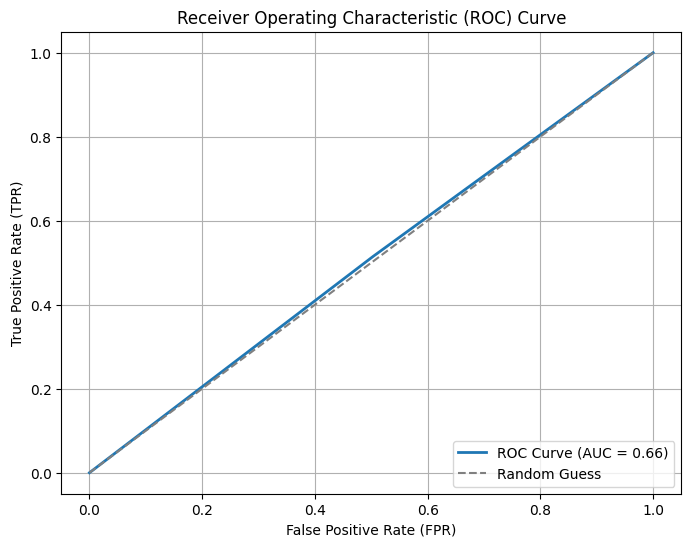

In [215]:
# Compute the AUC score
roc_auc = roc_auc_score(y_test, y_pred_adjusted_xgb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")  # Diagonal line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Stacking

In [112]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


# Define base models
base_models = [
    ('logreg', best_log_reg),
    ('dt', best_dt),
    ('rf', best_rf),
    ('xgb', best_xgb)
]

# Define meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=RSEED)

# Initialize stacking classifier
stacking_model = StackingClassifier(
    estimators=base_models,         # Pre-tuned base models
    final_estimator=meta_model,     # Meta-model
    cv=5                            # Cross-validation for base models
)

# Train the stacking model
stacking_model.fit(X_train_fe_all_smote, y_train_smote)

# Make predictions
y_pred_stacking = stacking_model.predict(X_test_fe_all)

# Evaluate the stacking model
print("\nClassification Report for Stacking Classifier:\n")
print(classification_report(y_test, y_pred_stacking))



Classification Report for Stacking Classifier:

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97     25586
         1.0       0.24      0.09      0.14      1513

    accuracy                           0.93     27099
   macro avg       0.60      0.54      0.55     27099
weighted avg       0.91      0.93      0.92     27099



In [113]:
roc_auc_stacking = roc_auc_score(y_test, y_pred_stacking)
roc_auc_stacking

0.5386000269996466